In [2]:
from system_check import *
CUDA_state_print()

CUDA доступна: True
Количество GPU: 4

GPU #0:
Название: Tesla V100-SXM3-32GB
Вычислительная способность (CUDA Capability): (7, 0)
Объем памяти: 31.73 GB

GPU #1:
Название: Tesla V100-SXM3-32GB
Вычислительная способность (CUDA Capability): (7, 0)
Объем памяти: 31.73 GB

GPU #2:
Название: Tesla V100-SXM3-32GB
Вычислительная способность (CUDA Capability): (7, 0)
Объем памяти: 31.73 GB

GPU #3:
Название: Tesla V100-SXM3-32GB
Вычислительная способность (CUDA Capability): (7, 0)
Объем памяти: 31.73 GB


In [3]:
import sys
sys.path.append("/global_functions")
from global_functions.global_functions import *

------------------------------------
---> Choosing resource
---> Result of torch.cuda.is_available():
True
---> Final resource
-----> CUDA: 1
-----> device: cuda:1
------------------------------------


/home/pmartynyuk/UnTIE project/untie_venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
loading file vocab.json
loading file merges.txt
loading file tokenizer.json
loading file added_tokens.json
loading file special_tokens_map.json
loading file tokenizer_config.json
loading file chat_template.jinja
loading configuration file /home/pmartynyuk/UnTIE project/scripts/models_processing/models/eng_sentence_transformer_model/config.json
Model config BertConfig {
  "architectures": [
    "BertModel"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 1024,
  "initializer_range": 0.02,
  "intermediate_size": 4096,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_t

In [4]:
datasets_results_path = "../datasets_results"
res_name = "results_keys_01.json"

df_res = load_dataframe_from_json(f"{datasets_results_path}/{res_name}")

df_res.head()

,doc_id,original_text,tasks_cleaned,first_answer,score_chunk_strategy,choose_cluster_strategy,choose_answer_strategy,final_answer,base_metrics,corrected_metrics
0,000f90380d768a85e2316225854fc377c079b5c4,Full - Resolution Residual Networks for Semant...,"[Semantic Segmentation, Real-Time Semantic Seg...",semantic segmentation,only_score_diff,highest_avg_score,highest_chunk_score,Semantic image segmentation,"{'cosine_sim': 0.9999997615814209, 'lev_dist': 2}","{'cosine_sim': 0.9270111322402954, 'lev_dist': 7}"
1,000f90380d768a85e2316225854fc377c079b5c4,Full - Resolution Residual Networks for Semant...,"[Semantic Segmentation, Real-Time Semantic Seg...",semantic segmentation,only_weight,highest_avg_score,highest_chunk_score,Semantic image segmentation,"{'cosine_sim': 0.9999997615814209, 'lev_dist': 2}","{'cosine_sim': 0.9270111322402954, 'lev_dist': 7}"
2,000f90380d768a85e2316225854fc377c079b5c4,Full - Resolution Residual Networks for Semant...,"[Semantic Segmentation, Real-Time Semantic Seg...",semantic segmentation,equal_weight_score_diff,highest_avg_score,highest_chunk_score,Semantic image segmentation,"{'cosine_sim': 0.9999997615814209, 'lev_dist': 2}","{'cosine_sim': 0.9270111322402954, 'lev_dist': 7}"
3,000f90380d768a85e2316225854fc377c079b5c4,Full - Resolution Residual Networks for Semant...,"[Semantic Segmentation, Real-Time Semantic Seg...",semantic segmentation,only_score_diff,highest_avg_score,highest_similarity,Semantic image segmentation,"{'cosine_sim': 0.9999997615814209, 'lev_dist': 2}","{'cosine_sim': 0.9270111322402954, 'lev_dist': 7}"
4,000f90380d768a85e2316225854fc377c079b5c4,Full - Resolution Residual Networks for Semant...,"[Semantic Segmentation, Real-Time Semantic Seg...",semantic segmentation,only_weight,highest_avg_score,highest_similarity,Semantic image segmentation,"{'cosine_sim': 0.9999997615814209, 'lev_dist': 2}","{'cosine_sim': 0.9270111322402954, 'lev_dist': 7}"


In [5]:
df_res.shape

(8287, 10)

In [6]:
df_res.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8287 entries, 0 to 8286
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   doc_id                   8287 non-null   object
 1   original_text            8287 non-null   object
 2   tasks_cleaned            8287 non-null   object
 3   first_answer             8287 non-null   object
 4   score_chunk_strategy     8287 non-null   object
 5   choose_cluster_strategy  8287 non-null   object
 6   choose_answer_strategy   8287 non-null   object
 7   final_answer             8287 non-null   object
 8   base_metrics             8287 non-null   object
 9   corrected_metrics        8287 non-null   object
dtypes: object(10)
memory usage: 647.5+ KB


In [7]:
# Находим строки, где final_answer содержит "--No valid answers--"
no_valid_answers_df = df_res[df_res['final_answer'] == "--No valid answers--"]
no_valid_answers_df.shape

(25, 10)

In [8]:
no_valid_answers_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25 entries, 27 to 8151
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   doc_id                   25 non-null     object
 1   original_text            25 non-null     object
 2   tasks_cleaned            25 non-null     object
 3   first_answer             25 non-null     object
 4   score_chunk_strategy     25 non-null     object
 5   choose_cluster_strategy  25 non-null     object
 6   choose_answer_strategy   25 non-null     object
 7   final_answer             25 non-null     object
 8   base_metrics             25 non-null     object
 9   corrected_metrics        25 non-null     object
dtypes: object(10)
memory usage: 2.1+ KB


In [9]:
unique_doc_ids = no_valid_answers_df['doc_id'].unique()
print(f"Уникальные doc_id: {unique_doc_ids}")
print(f"Количество уникальных значений: {len(unique_doc_ids)}")

Уникальные doc_id: ['0012de6bec1f25599e4f02517637e531a71909b9'
 '0095c269e7d0c990249312687fc43521019809c4'
 '0373b97580cdfd0b69f165e1a946bae62da95dce'
 '052282998bc24db695891f755a00e3cebd3fd796'
 '052443e1709c0f7d3432cca7c451534eea76b7ca'
 '07045f87709d0b7b998794e9fa912c0aba912281'
 '0b0cf7e00e7532e38238a9164f0a8db2574be2ea'
 '0c278ecf472f42ec1140ca2f1a0a3dd60cbe5c48'
 '0d467adaf936b112f570970c5210bdb3c626a717'
 '0f810eb4777fd05317951ebaa7a3f5835ee84cf4'
 '121e30c48546e671dc5e16c694c5e69b392cf8fb'
 '12e20e4ea572dbe476fd894c5c9a9930cf250dd2'
 '13b58f3108709dbbed5588759bc0496f82a261c4'
 '15212fa4d30863ea1f9bd9591eee03848278242d'
 '1a5ea605111eb3403868d4b679315e944beee8c6'
 '1f76b7b071f3e65c97d09720f88d6b0ad9f07e8f'
 '22aab110058ebbd198edb1f1e7b4f69fb13c0613'
 '26fe009b958e8728382d9d764bd7153632f0b869'
 '289e91654f6da968d625481ef21f52892052d4fc'
 '2cb8497f9214735ffd1bd57db645794459b8ff41'
 '2d2a22f1f9eae9188f3d43254daa2d5b7f3a2470'
 '32a93598e8a338496f04a0ace81b0768c2ef059d'
 '39dba6f22d7

In [10]:
# Все остальные строки (используем инверсию условия)
res_done_df = df_res[df_res['final_answer'] != "--No valid answers--"]
res_done_df.shape

(8262, 10)

In [11]:
res_done_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8262 entries, 0 to 8286
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   doc_id                   8262 non-null   object
 1   original_text            8262 non-null   object
 2   tasks_cleaned            8262 non-null   object
 3   first_answer             8262 non-null   object
 4   score_chunk_strategy     8262 non-null   object
 5   choose_cluster_strategy  8262 non-null   object
 6   choose_answer_strategy   8262 non-null   object
 7   final_answer             8262 non-null   object
 8   base_metrics             8262 non-null   object
 9   corrected_metrics        8262 non-null   object
dtypes: object(10)
memory usage: 710.0+ KB


In [12]:
res_done_df[25:30]

,doc_id,original_text,tasks_cleaned,first_answer,score_chunk_strategy,choose_cluster_strategy,choose_answer_strategy,final_answer,base_metrics,corrected_metrics
25,000f90380d768a85e2316225854fc377c079b5c4,Full - Resolution Residual Networks for Semant...,"[Semantic Segmentation, Real-Time Semantic Seg...",semantic segmentation,only_weight,highest_cohesion,combined_score,Semantic image segmentation,"{'cosine_sim': 0.9999997615814209, 'lev_dist': 2}","{'cosine_sim': 0.9270111322402954, 'lev_dist': 7}"
26,000f90380d768a85e2316225854fc377c079b5c4,Full - Resolution Residual Networks for Semant...,"[Semantic Segmentation, Real-Time Semantic Seg...",semantic segmentation,equal_weight_score_diff,highest_cohesion,combined_score,Semantic image segmentation,"{'cosine_sim': 0.9999997615814209, 'lev_dist': 2}","{'cosine_sim': 0.9270111322402954, 'lev_dist': 7}"
28,0012de6bec1f25599e4f02517637e531a71909b9,document: V - Net: Fully Convolutional Neural ...,[Volumetric Medical Image Segmentation],classification task,only_score_diff,highest_avg_score,highest_chunk_score,"classification, segmentation and object detection","{'cosine_sim': 0.6106195449829102, 'lev_dist':...","{'cosine_sim': 0.5831809639930725, 'lev_dist':..."
29,0012de6bec1f25599e4f02517637e531a71909b9,document: V - Net: Fully Convolutional Neural ...,[Volumetric Medical Image Segmentation],classification task,only_weight,highest_avg_score,highest_chunk_score,"classification, segmentation and object detection","{'cosine_sim': 0.6106195449829102, 'lev_dist':...","{'cosine_sim': 0.5831809639930725, 'lev_dist':..."
30,0012de6bec1f25599e4f02517637e531a71909b9,document: V - Net: Fully Convolutional Neural ...,[Volumetric Medical Image Segmentation],classification task,equal_weight_score_diff,highest_avg_score,highest_chunk_score,"classification, segmentation and object detection","{'cosine_sim': 0.6106195449829102, 'lev_dist':...","{'cosine_sim': 0.5831809639930725, 'lev_dist':..."


In [13]:
# Если unique_doc_ids - это массив/список/множество
res_done_df = res_done_df[~res_done_df['doc_id'].isin(unique_doc_ids)]

In [14]:
res_done_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7587 entries, 0 to 8286
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   doc_id                   7587 non-null   object
 1   original_text            7587 non-null   object
 2   tasks_cleaned            7587 non-null   object
 3   first_answer             7587 non-null   object
 4   score_chunk_strategy     7587 non-null   object
 5   choose_cluster_strategy  7587 non-null   object
 6   choose_answer_strategy   7587 non-null   object
 7   final_answer             7587 non-null   object
 8   base_metrics             7587 non-null   object
 9   corrected_metrics        7587 non-null   object
dtypes: object(10)
memory usage: 652.0+ KB


In [15]:
# Создаем словарь групп
groups = {}
for (score_strat, cluster_strat, answer_strat), group_df in res_done_df.groupby([
    'score_chunk_strategy', 
    'choose_cluster_strategy', 
    'choose_answer_strategy'
]):
    key = f"{score_strat}_{cluster_strat}_{answer_strat}"
    groups[key] = group_df
    print(f"Группа {key}: {len(group_df)} строк")

# Теперь у вас есть словарь groups с 27 датафреймами
# Обращение к конкретной группе:
# groups['strategy1_strategy2_strategy3']

Группа equal_weight_score_diff_highest_avg_score_combined_score: 281 строк
Группа equal_weight_score_diff_highest_avg_score_highest_chunk_score: 281 строк
Группа equal_weight_score_diff_highest_avg_score_highest_similarity: 281 строк
Группа equal_weight_score_diff_highest_cohesion_combined_score: 281 строк
Группа equal_weight_score_diff_highest_cohesion_highest_chunk_score: 281 строк
Группа equal_weight_score_diff_highest_cohesion_highest_similarity: 281 строк
Группа equal_weight_score_diff_weighted_score_combined_score: 281 строк
Группа equal_weight_score_diff_weighted_score_highest_chunk_score: 281 строк
Группа equal_weight_score_diff_weighted_score_highest_similarity: 281 строк
Группа only_score_diff_highest_avg_score_combined_score: 281 строк
Группа only_score_diff_highest_avg_score_highest_chunk_score: 281 строк
Группа only_score_diff_highest_avg_score_highest_similarity: 281 строк
Группа only_score_diff_highest_cohesion_combined_score: 281 строк
Группа only_score_diff_highest_coh

In [16]:
groups["equal_weight_score_diff_highest_avg_score_combined_score"]

,doc_id,original_text,tasks_cleaned,first_answer,score_chunk_strategy,choose_cluster_strategy,choose_answer_strategy,final_answer,base_metrics,corrected_metrics
8,000f90380d768a85e2316225854fc377c079b5c4,Full - Resolution Residual Networks for Semant...,"[Semantic Segmentation, Real-Time Semantic Seg...",semantic segmentation,equal_weight_score_diff,highest_avg_score,combined_score,Semantic image segmentation,"{'cosine_sim': 0.9999997615814209, 'lev_dist': 2}","{'cosine_sim': 0.9270111322402954, 'lev_dist': 7}"
63,007ab5528b3bd310a80d553cccad4b78dc496b02,document: Bi - Directional Attention Flow for ...,"[Question Answering, Open-Domain Question Answ...",query - to - context attention,equal_weight_score_diff,highest_avg_score,combined_score,Model Details,"{'cosine_sim': 0.8159458041191101, 'lev_dist':...","{'cosine_sim': 0.6737011671066284, 'lev_dist':..."
118,00b1cdc5bd77bf27f9b1ca630365eeeb456913b4,document: Mastering Chess and Shogi by Self - ...,"[Game of Go, Game of Shogi]",compute the game outcome,equal_weight_score_diff,highest_avg_score,combined_score,compute the game outcome,"{'cosine_sim': 0.7179353833198547, 'lev_dist':...","{'cosine_sim': 0.7179353833198547, 'lev_dist':..."
145,01125e3c68edb420b8d884ff53fb38d9fbe4f2b8,document: Large Pose 3D Face Reconstruction fr...,[3D Face Reconstruction],3D facial landmark localisation,equal_weight_score_diff,highest_avg_score,combined_score,3D facial landmark localisation,"{'cosine_sim': 0.9436883926391602, 'lev_dist':...","{'cosine_sim': 0.9436883926391602, 'lev_dist':..."
172,0116899fce00ffa4afee08b505300bb3968faf9f,Long Text Generation via Adversarial Training ...,[Text Generation],adversarial training,equal_weight_score_diff,highest_avg_score,combined_score,whole text generation,"{'cosine_sim': 0.49332764744758606, 'lev_dist'...","{'cosine_sim': 0.8032681345939636, 'lev_dist': 8}"
...,...,...,...,...,...,...,...,...,...,...
8132,454dd76eb0a82286c054a6dd9d9413e09ad66801,document: Graph - Structured Representations f...,[Visual Question Answering],Visual Question Answering,equal_weight_score_diff,highest_avg_score,combined_score,Visual Question Answering,"{'cosine_sim': 1.0, 'lev_dist': 0}","{'cosine_sim': 1.0, 'lev_dist': 0}"
8187,45e8ef229fae18b0a2ab328037d8e520866c3c81,document: Learning Feature Pyramids for Human ...,[Pose Estimation],human pose estimation,equal_weight_score_diff,highest_avg_score,combined_score,human pose estimation,"{'cosine_sim': 0.8518654108047485, 'lev_dist': 8}","{'cosine_sim': 0.8518654108047485, 'lev_dist': 8}"
8214,45fdc73a239e9c6ea65e98c96f6a2d6dc35d6f72,document: Quaternion Convolutional Neural Netw...,[Speech Recognition],TIMIT phonemes recognition task,equal_weight_score_diff,highest_avg_score,combined_score,CIFAR images classification task,"{'cosine_sim': 0.7668201923370361, 'lev_dist':...","{'cosine_sim': 0.6065893173217773, 'lev_dist':..."
8241,46018a894d533813d67322827ca51f78aed6d59e,document: Brain Tumor Segmentation with Deep N...,[Brain Tumor Segmentation],brain tumor segmentation,equal_weight_score_diff,highest_avg_score,combined_score,brain tumor segmentation,"{'cosine_sim': 1.0000001192092896, 'lev_dist': 3}","{'cosine_sim': 1.0000001192092896, 'lev_dist': 3}"


In [17]:
import json
import pandas as pd
import numpy as np
from collections import defaultdict

# Функция для парсинга метрик
def parse_metrics(metrics_str):
    try:
        metrics = json.loads(metrics_str.replace("'", "\""))
        return metrics.get('cosine_sim', 0), metrics.get('lev_dist', 0)
    except:
        return 0, 0

# Словари для хранения результатов
results_summary = {}
detailed_analysis = {}

# Анализируем каждую группу
for group_name, group_df in groups.items():
    print(f"\n{'='*60}")
    print(f"АНАЛИЗ ГРУППЫ: {group_name}")
    print(f"{'='*60}")
    
    # Парсим метрики
    cosine_sim_base = []
    lev_dist_base = []
    cosine_sim_corrected = []
    lev_dist_corrected = []
    cosine_sim_diff = []
    lev_dist_diff = []
    
    for idx, row in group_df.iterrows():
        try:
            # Парсим base_metrics
            cos_base, lev_base = parse_metrics(row['base_metrics'])
            cosine_sim_base.append(cos_base)
            lev_dist_base.append(lev_base)
            
            # Парсим corrected_metrics
            cos_corr, lev_corr = parse_metrics(row['corrected_metrics'])
            cosine_sim_corrected.append(cos_corr)
            lev_dist_corrected.append(lev_corr)
            
            # Вычисляем разницы
            cosine_sim_diff.append(cos_corr - cos_base)
            lev_dist_diff.append(lev_corr - lev_base)
            
        except Exception as e:
            print(f"Ошибка парсинга для строки {idx}: {e}")
            continue
    
    # Создаем DataFrame для анализа
    analysis_df = pd.DataFrame({
        'cosine_sim_base': cosine_sim_base,
        'cosine_sim_corrected': cosine_sim_corrected,
        'cosine_sim_diff': cosine_sim_diff,
        'lev_dist_base': lev_dist_base,
        'lev_dist_corrected': lev_dist_corrected,
        'lev_dist_diff': lev_dist_diff
    })
    
    # Анализ улучшений/ухудшений
    # Для cosine_sim: улучшение = diff > 0, ухудшение = diff < 0
    cosine_improved = sum(1 for diff in cosine_sim_diff if diff > 0)
    cosine_worsened = sum(1 for diff in cosine_sim_diff if diff < 0)
    cosine_unchanged = sum(1 for diff in cosine_sim_diff if diff == 0)
    
    # Для lev_dist: улучшение = diff < 0, ухудшение = diff > 0
    lev_improved = sum(1 for diff in lev_dist_diff if diff < 0)
    lev_worsened = sum(1 for diff in lev_dist_diff if diff > 0)
    lev_unchanged = sum(1 for diff in lev_dist_diff if diff == 0)
    
    # Общая оценка улучшения (улучшилась хотя бы одна метрика без ухудшения другой)
    overall_improved = 0
    overall_worsened = 0
    overall_mixed = 0
    overall_unchanged = 0
    
    for cos_diff, lev_diff in zip(cosine_sim_diff, lev_dist_diff):
        if cos_diff > 0 and lev_diff < 0:
            overall_improved += 1  # Улучшились обе метрики
        elif cos_diff < 0 and lev_diff > 0:
            overall_worsened += 1  # Ухудшились обе метрики
        elif cos_diff == 0 and lev_diff == 0:
            overall_unchanged += 1  # Ничего не изменилось
        else:
            overall_mixed += 1  # Смешанный результат
    
    # Сохраняем детальный анализ
    detailed_analysis[group_name] = analysis_df
    
    # Сохраняем суммарную статистику
    results_summary[group_name] = {
        'total_samples': len(analysis_df),
        
        # Cosine similarity
        'cosine_improved': cosine_improved,
        'cosine_improved_pct': cosine_improved / len(analysis_df) * 100,
        'cosine_worsened': cosine_worsened,
        'cosine_worsened_pct': cosine_worsened / len(analysis_df) * 100,
        'cosine_unchanged': cosine_unchanged,
        'cosine_unchanged_pct': cosine_unchanged / len(analysis_df) * 100,
        
        # Levenshtein distance
        'lev_improved': lev_improved,
        'lev_improved_pct': lev_improved / len(analysis_df) * 100,
        'lev_worsened': lev_worsened,
        'lev_worsened_pct': lev_worsened / len(analysis_df) * 100,
        'lev_unchanged': lev_unchanged,
        'lev_unchanged_pct': lev_unchanged / len(analysis_df) * 100,
        
        # Общая оценка
        'overall_improved': overall_improved,
        'overall_improved_pct': overall_improved / len(analysis_df) * 100,
        'overall_worsened': overall_worsened,
        'overall_worsened_pct': overall_worsened / len(analysis_df) * 100,
        'overall_mixed': overall_mixed,
        'overall_mixed_pct': overall_mixed / len(analysis_df) * 100,
        'overall_unchanged': overall_unchanged,
        'overall_unchanged_pct': overall_unchanged / len(analysis_df) * 100,
        
        # Статистики по изменениям
        'cosine_mean_diff': np.mean(cosine_sim_diff),
        'cosine_std_diff': np.std(cosine_sim_diff),
        'lev_mean_diff': np.mean(lev_dist_diff),
        'lev_std_diff': np.std(lev_dist_diff)
    }
    
    # Выводим результаты для текущей группы
    print(f"Общее количество samples: {len(analysis_df)}")
    print(f"\n--- Cosine Similarity ---")
    print(f"Улучшилось: {cosine_improved} ({cosine_improved/len(analysis_df)*100:.1f}%)")
    print(f"Ухудшилось: {cosine_worsened} ({cosine_worsened/len(analysis_df)*100:.1f}%)")
    print(f"Не изменилось: {cosine_unchanged} ({cosine_unchanged/len(analysis_df)*100:.1f}%)")
    
    print(f"\n--- Levenshtein Distance ---")
    print(f"Улучшилось: {lev_improved} ({lev_improved/len(analysis_df)*100:.1f}%)")
    print(f"Ухудшилось: {lev_worsened} ({lev_worsened/len(analysis_df)*100:.1f}%)")
    print(f"Не изменилось: {lev_unchanged} ({lev_unchanged/len(analysis_df)*100:.1f}%)")
    
    print(f"\n--- Общая оценка ---")
    print(f"Полное улучшение: {overall_improved} ({overall_improved/len(analysis_df)*100:.1f}%)")
    print(f"Полное ухудшение: {overall_worsened} ({overall_worsened/len(analysis_df)*100:.1f}%)")
    print(f"Смешанный результат: {overall_mixed} ({overall_mixed/len(analysis_df)*100:.1f}%)")
    print(f"Без изменений: {overall_unchanged} ({overall_unchanged/len(analysis_df)*100:.1f}%)")
    
    print(f"\n--- Статистики изменений ---")
    print(f"Cosine similarity: среднее изменение = {np.mean(cosine_sim_diff):.4f} ± {np.std(cosine_sim_diff):.4f}")
    print(f"Levenshtein distance: среднее изменение = {np.mean(lev_dist_diff):.2f} ± {np.std(lev_dist_diff):.2f}")

# Создаем суммарный DataFrame для сравнения всех групп
summary_df = pd.DataFrame.from_dict(results_summary, orient='index')

# Сортируем по общему улучшению
summary_df_sorted = summary_df.sort_values('overall_improved_pct', ascending=False)

print(f"\n{'='*80}")
print(f"ОБЩАЯ СТАТИСТИКА ПО ВСЕМ ГРУППАМ")
print(f"{'='*80}")
print(f"\nТоп-5 групп по проценту полного улучшения:")
print(summary_df_sorted[['overall_improved_pct', 'overall_worsened_pct', 'overall_mixed_pct', 'overall_unchanged_pct']].head())

# Анализ по типам стратегий
print(f"\n{'='*50}")
print(f"АНАЛИЗ ПО ТИПАМ СТРАТЕГИЙ")
print(f"{'='*50}")

# Извлекаем компоненты стратегий из названий групп
strategy_components = []
for group_name in groups.keys():
    parts = group_name.split('_')
    # Предполагаемая структура: prefix_score_strat_cluster_strat_answer_strat
    score_strat = '_'.join(parts[0:3])  # first 3 parts
    cluster_strat = '_'.join(parts[3:5])  # next 2 parts  
    answer_strat = '_'.join(parts[5:])   # remaining parts
    
    strategy_components.append({
        'group': group_name,
        'score_strategy': score_strat,
        'cluster_strategy': cluster_strat,
        'answer_strategy': answer_strat,
        'overall_improved_pct': results_summary[group_name]['overall_improved_pct']
    })

strategy_df = pd.DataFrame(strategy_components)

# Анализ эффективности по типам стратегий
print("\nЭффективность по Score стратегиям:")
print(strategy_df.groupby('score_strategy')['overall_improved_pct'].agg(['mean', 'std', 'count']))

print("\nЭффективность по Cluster стратегиям:")
print(strategy_df.groupby('cluster_strategy')['overall_improved_pct'].agg(['mean', 'std', 'count']))

print("\nЭффективность по Answer стратегиям:")
print(strategy_df.groupby('answer_strategy')['overall_improved_pct'].agg(['mean', 'std', 'count']))

# Сохранение результатов
summary_df_sorted.to_csv('metrics_analysis_summary.csv', encoding='utf-8')
print(f"\nРезультаты сохранены в 'metrics_analysis_summary.csv'")


АНАЛИЗ ГРУППЫ: equal_weight_score_diff_highest_avg_score_combined_score
Общее количество samples: 281

--- Cosine Similarity ---
Улучшилось: 185 (65.8%)
Ухудшилось: 42 (14.9%)
Не изменилось: 54 (19.2%)

--- Levenshtein Distance ---
Улучшилось: 141 (50.2%)
Ухудшилось: 78 (27.8%)
Не изменилось: 62 (22.1%)

--- Общая оценка ---
Полное улучшение: 132 (47.0%)
Полное ухудшение: 32 (11.4%)
Смешанный результат: 65 (23.1%)
Без изменений: 52 (18.5%)

--- Статистики изменений ---
Cosine similarity: среднее изменение = 0.1027 ± 0.2139
Levenshtein distance: среднее изменение = -2.95 ± 14.10

АНАЛИЗ ГРУППЫ: equal_weight_score_diff_highest_avg_score_highest_chunk_score
Общее количество samples: 281

--- Cosine Similarity ---
Улучшилось: 185 (65.8%)
Ухудшилось: 42 (14.9%)
Не изменилось: 54 (19.2%)

--- Levenshtein Distance ---
Улучшилось: 141 (50.2%)
Ухудшилось: 78 (27.8%)
Не изменилось: 62 (22.1%)

--- Общая оценка ---
Полное улучшение: 132 (47.0%)
Полное ухудшение: 32 (11.4%)
Смешанный результат: 6

In [18]:
import pandas as pd

# Загрузка CSV в DataFrame
df = pd.read_csv('metrics_analysis_summary.csv', index_col=0)

df

,total_samples,cosine_improved,cosine_improved_pct,cosine_worsened,cosine_worsened_pct,cosine_unchanged,cosine_unchanged_pct,lev_improved,lev_improved_pct,lev_worsened,...,overall_worsened,overall_worsened_pct,overall_mixed,overall_mixed_pct,overall_unchanged,overall_unchanged_pct,cosine_mean_diff,cosine_std_diff,lev_mean_diff,lev_std_diff
only_weight_weighted_score_combined_score,281,199,70.818505,13,4.626335,69,24.555160,153,54.448399,51,...,9,3.202847,54,19.217082,68,24.199288,0.144857,0.156717,-5.213523,12.271425
equal_weight_score_diff_weighted_score_highest_chunk_score,281,199,70.818505,14,4.982206,68,24.199288,151,53.736655,53,...,10,3.558719,56,19.928826,66,23.487544,0.144012,0.156750,-5.064057,12.021755
equal_weight_score_diff_weighted_score_combined_score,281,199,70.818505,13,4.626335,69,24.555160,151,53.736655,52,...,9,3.202847,56,19.928826,67,23.843416,0.144139,0.156620,-5.120996,11.959583
only_score_diff_weighted_score_combined_score,281,199,70.818505,14,4.982206,68,24.199288,151,53.736655,53,...,10,3.558719,56,19.928826,66,23.487544,0.144012,0.156750,-5.064057,12.021755
only_weight_weighted_score_highest_chunk_score,281,199,70.818505,14,4.982206,68,24.199288,152,54.092527,53,...,10,3.558719,55,19.572954,67,23.843416,0.143884,0.156866,-4.982206,12.443597
only_score_diff_weighted_score_highest_chunk_score,281,199,70.818505,14,4.982206,68,24.199288,151,53.736655,53,...,10,3.558719,56,19.928826,66,23.487544,0.144012,0.156750,-5.064057,12.021755
only_weight_highest_avg_score_combined_score,281,189,67.259786,40,14.234875,52,18.505338,143,50.889680,78,...,33,11.743772,60,21.352313,51,18.149466,0.108602,0.211499,-3.416370,13.614453
only_weight_highest_avg_score_highest_chunk_score,281,189,67.259786,40,14.234875,52,18.505338,143,50.889680,78,...,33,11.743772,60,21.352313,51,18.149466,0.108173,0.210952,-3.323843,13.662627
equal_weight_score_diff_highest_avg_score_highest_chunk_score,281,185,65.836299,42,14.946619,54,19.217082,141,50.177936,78,...,32,11.387900,65,23.131673,52,18.505338,0.102665,0.213898,-2.950178,14.097689
only_score_diff_highest_avg_score_combined_score,281,185,65.836299,42,14.946619,54,19.217082,141,50.177936,78,...,32,11.387900,65,23.131673,52,18.505338,0.102665,0.213898,-2.950178,14.097689


In [19]:
# Выбираем топ-групп по разным критериям
print("ТОП-3 группы по полному улучшению (обе метрики улучшились):")
top_overall = df.nlargest(3, 'overall_improved_pct')
print(top_overall[['overall_improved_pct', 'overall_worsened_pct']])

print("\nТОП-3 группы по улучшению Cosine Similarity:")
top_cosine = df.nlargest(3, 'cosine_improved_pct')
print(top_cosine[['cosine_improved_pct', 'cosine_worsened_pct', 'cosine_mean_diff']])

print("\nТОП-3 группы по улучшению Levenshtein Distance:")
top_lev = df.nlargest(3, 'lev_improved_pct')
print(top_lev[['lev_improved_pct', 'lev_worsened_pct', 'lev_mean_diff']])

print("\nТОП-3 группы по наименьшему ухудшению:")
least_worsened = df.nsmallest(3, 'overall_worsened_pct')
print(least_worsened[['overall_improved_pct', 'overall_worsened_pct']])

# Комплексный рейтинг (можно взвешивать метрики по важности)
df['composite_score'] = (
    df['overall_improved_pct'] * 0.4 + 
    df['cosine_improved_pct'] * 0.3 + 
    df['lev_improved_pct'] * 0.3 -
    df['overall_worsened_pct'] * 0.2
)

print("\nТОП-5 групп по композитному score:")
top_composite = df.nlargest(5, 'composite_score')
print(top_composite[['composite_score', 'overall_improved_pct', 'cosine_improved_pct', 'lev_improved_pct']])

# Лучшая группа по композитному score
best_group = df.nlargest(1, 'composite_score')
print(f"\n🎯 ЛУЧШАЯ ГРУППА: {best_group.index[0]}")
print(f"Композитный score: {best_group['composite_score'].iloc[0]:.2f}")
print(f"Полное улучшение: {best_group['overall_improved_pct'].iloc[0]:.1f}%")
print(f"Улучшение Cosine: {best_group['cosine_improved_pct'].iloc[0]:.1f}%") 
print(f"Улучшение Levenshtein: {best_group['lev_improved_pct'].iloc[0]:.1f}%")

ТОП-3 группы по полному улучшению (обе метрики улучшились):
                                                    overall_improved_pct  \
only_weight_weighted_score_combined_score                      53.380783   
equal_weight_score_diff_weighted_score_highest_...             53.024911   
equal_weight_score_diff_weighted_score_combined...             53.024911   

                                                    overall_worsened_pct  
only_weight_weighted_score_combined_score                       3.202847  
equal_weight_score_diff_weighted_score_highest_...              3.558719  
equal_weight_score_diff_weighted_score_combined...              3.202847  

ТОП-3 группы по улучшению Cosine Similarity:
                                                    cosine_improved_pct  \
only_weight_weighted_score_combined_score                     70.818505   
equal_weight_score_diff_weighted_score_highest_...            70.818505   
equal_weight_score_diff_weighted_score_combined...            70

АНАЛИЗ ЭФФЕКТИВНОСТИ ОТДЕЛЬНЫХ СТРАТЕГИЙ

Score стратегии:
                         overall_improved_pct  cosine_improved_pct  \
score_chunk_strategy                                                 
equal_weight_score_diff                 35.51                50.42   
only_score_diff                         35.51                50.42   
only_weight                             36.30                51.09   

                         lev_improved_pct  overall_worsened_pct  \
score_chunk_strategy                                              
equal_weight_score_diff             42.31                 19.73   
only_score_diff                     42.31                 19.77   
only_weight                         43.10                 19.45   

                         cosine_mean_diff  cosine_std_diff  lev_mean_diff  \
score_chunk_strategy                                                        
equal_weight_score_diff            0.0472           0.2170        -1.3286   
only_score_diff        

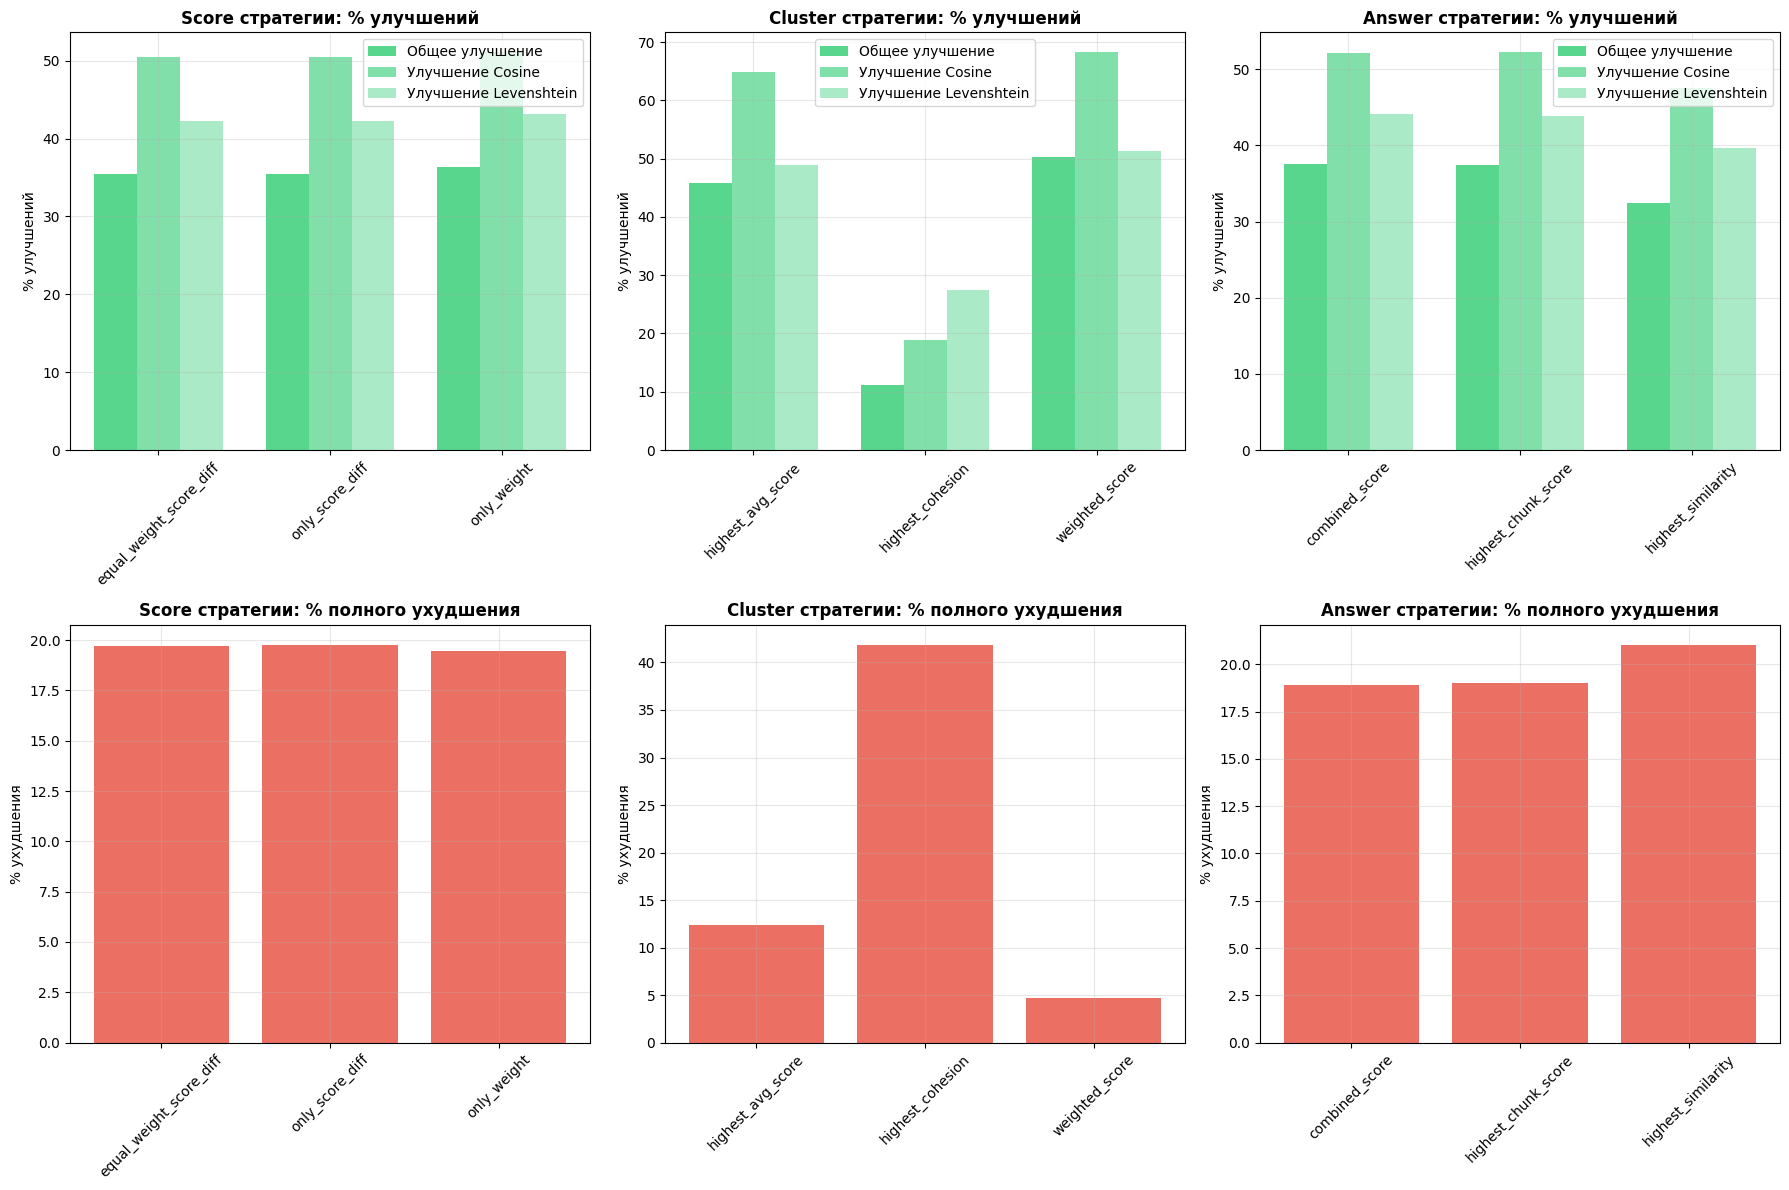


АНАЛИЗ КОМБИНАЦИЙ СТРАТЕГИЙ
Топ-10 комбинаций стратегий по общему улучшению:
                                                                        overall_improved_pct  \
score_chunk_strategy    choose_cluster_strategy choose_answer_strategy                         
only_weight             weighted_score          combined_score                         53.38   
equal_weight_score_diff weighted_score          highest_chunk_score                    53.02   
                                                combined_score                         53.02   
only_score_diff         weighted_score          combined_score                         53.02   
only_weight             weighted_score          highest_chunk_score                    53.02   
only_score_diff         weighted_score          highest_chunk_score                    53.02   
only_weight             highest_avg_score       combined_score                         48.75   
                                                highest_ch

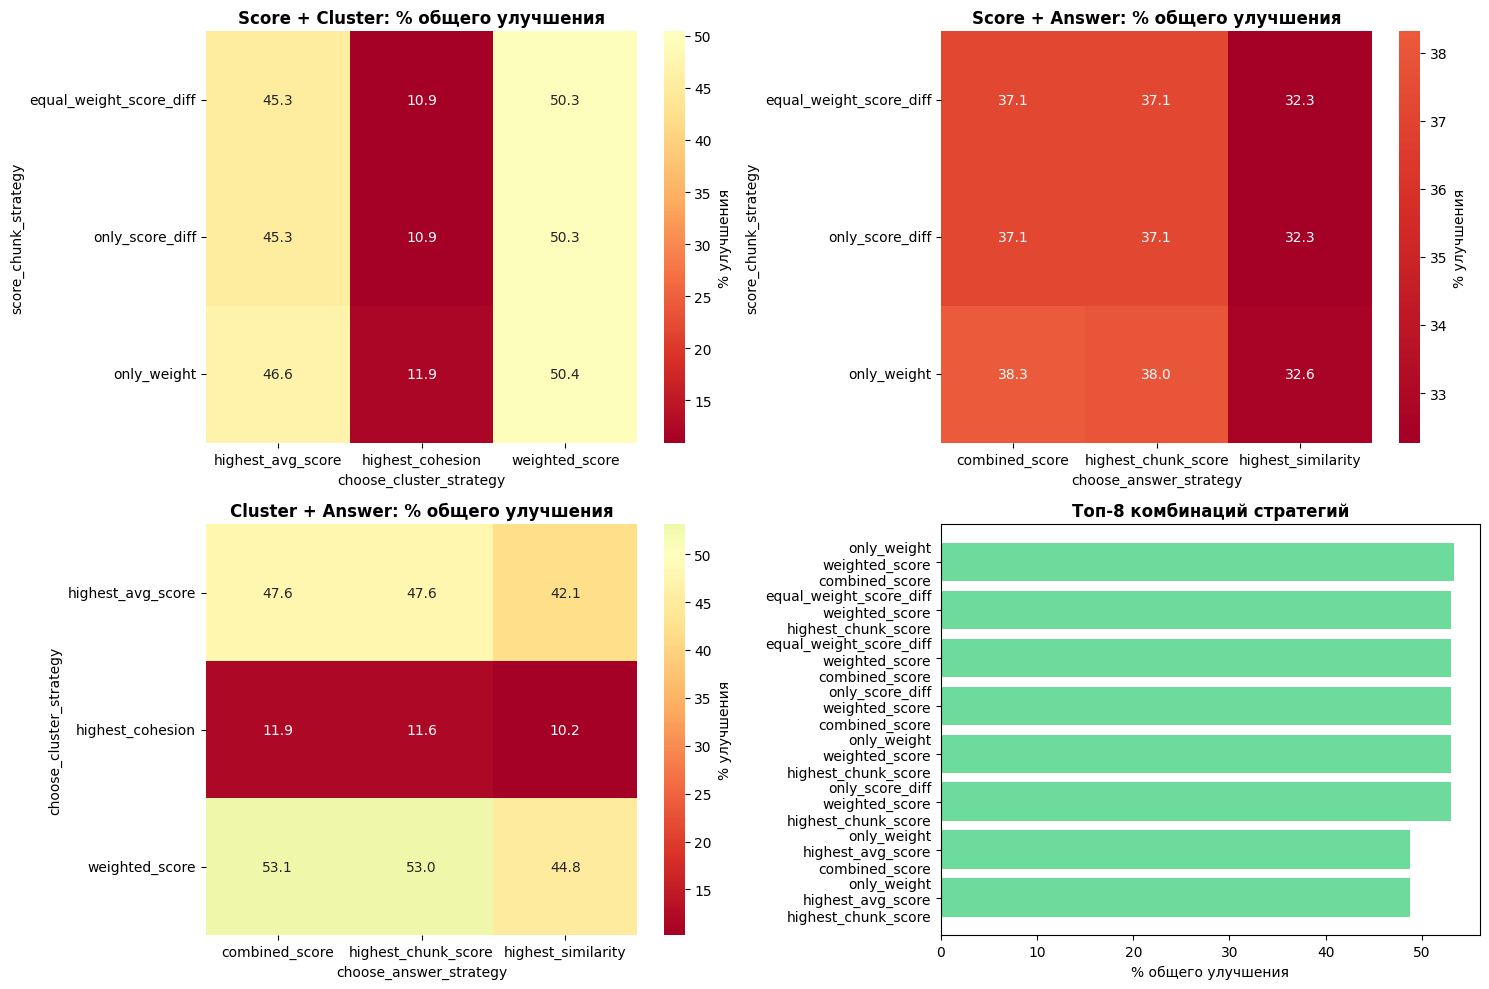


🎯 РЕКОМЕНДАЦИИ ПО СТРАТЕГИЯМ:
Лучшая Score стратегия: only_weight (36.3%)
Лучшая Cluster стратегия: weighted_score (50.3%)
Лучшая Answer стратегия: combined_score (37.5%)

🏆 ОПТИМАЛЬНАЯ КОМБИНАЦИЯ:
Score: only_weight
Cluster: weighted_score
Answer: combined_score
Результат: 53.4% полного улучшения
Количество примеров: 281.0


In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import json

# Настройка стиля и цветовой схемы
plt.style.use('default')
sns.set_palette("husl")
COLORS = {'improved': '#2ecc71', 'unchanged': '#f39c12', 'worsened': '#e74c3c'}

# Функция для парсинга метрик
def parse_metrics(metrics_str):
    try:
        metrics = json.loads(metrics_str.replace("'", "\""))
        return metrics.get('cosine_sim', 0), metrics.get('lev_dist', 0)
    except:
        return 0, 0

# 1. Создаем копию исходного датафрейма и парсим метрики
analysis_df = res_done_df.copy()

# Парсим метрики
cosine_sim_base = []
lev_dist_base = []
cosine_sim_corrected = []
lev_dist_corrected = []

for idx, row in analysis_df.iterrows():
    cos_base, lev_base = parse_metrics(row['base_metrics'])
    cos_corr, lev_corr = parse_metrics(row['corrected_metrics'])
    
    cosine_sim_base.append(cos_base)
    lev_dist_base.append(lev_base)
    cosine_sim_corrected.append(cos_corr)
    lev_dist_corrected.append(lev_corr)

# Добавляем распарсенные метрики в датафрейм
analysis_df['cosine_sim_base'] = cosine_sim_base
analysis_df['cosine_sim_corrected'] = cosine_sim_corrected
analysis_df['lev_dist_base'] = lev_dist_base
analysis_df['lev_dist_corrected'] = lev_dist_corrected

# Вычисляем разницы
analysis_df['cosine_sim_diff'] = analysis_df['cosine_sim_corrected'] - analysis_df['cosine_sim_base']
analysis_df['lev_dist_diff'] = analysis_df['lev_dist_corrected'] - analysis_df['lev_dist_base']

# Определяем улучшения/ухудшения
analysis_df['cosine_improved'] = analysis_df['cosine_sim_diff'] > 0
analysis_df['cosine_worsened'] = analysis_df['cosine_sim_diff'] < 0
analysis_df['cosine_unchanged'] = analysis_df['cosine_sim_diff'] == 0

analysis_df['lev_improved'] = analysis_df['lev_dist_diff'] < 0
analysis_df['lev_worsened'] = analysis_df['lev_dist_diff'] > 0
analysis_df['lev_unchanged'] = analysis_df['lev_dist_diff'] == 0

analysis_df['overall_improved'] = (analysis_df['cosine_improved']) & (analysis_df['lev_improved'])
analysis_df['overall_worsened'] = (analysis_df['cosine_worsened']) & (analysis_df['lev_worsened'])

# 2. Анализ эффективности отдельных стратегий
print("АНАЛИЗ ЭФФЕКТИВНОСТИ ОТДЕЛЬНЫХ СТРАТЕГИЙ")
print("=" * 50)

# Score стратегии
score_stats = analysis_df.groupby('score_chunk_strategy').agg({
    'overall_improved': 'mean',
    'cosine_improved': 'mean', 
    'lev_improved': 'mean',
    'overall_worsened': 'mean',
    'cosine_sim_diff': ['mean', 'std'],
    'lev_dist_diff': ['mean', 'std']
}).round(4)

score_stats.columns = ['overall_improved_pct', 'cosine_improved_pct', 'lev_improved_pct', 
                      'overall_worsened_pct', 'cosine_mean_diff', 'cosine_std_diff',
                      'lev_mean_diff', 'lev_std_diff']

# Переводим в проценты
for col in ['overall_improved_pct', 'cosine_improved_pct', 'lev_improved_pct', 'overall_worsened_pct']:
    score_stats[col] = score_stats[col] * 100

print("\nScore стратегии:")
print(score_stats)

# Cluster стратегии
cluster_stats = analysis_df.groupby('choose_cluster_strategy').agg({
    'overall_improved': 'mean',
    'cosine_improved': 'mean',
    'lev_improved': 'mean',
    'overall_worsened': 'mean',
    'cosine_sim_diff': ['mean', 'std'],
    'lev_dist_diff': ['mean', 'std']
}).round(4)

cluster_stats.columns = ['overall_improved_pct', 'cosine_improved_pct', 'lev_improved_pct', 
                        'overall_worsened_pct', 'cosine_mean_diff', 'cosine_std_diff',
                        'lev_mean_diff', 'lev_std_diff']

for col in ['overall_improved_pct', 'cosine_improved_pct', 'lev_improved_pct', 'overall_worsened_pct']:
    cluster_stats[col] = cluster_stats[col] * 100

print("\nCluster стратегии:")
print(cluster_stats)

# Answer стратегии
answer_stats = analysis_df.groupby('choose_answer_strategy').agg({
    'overall_improved': 'mean',
    'cosine_improved': 'mean',
    'lev_improved': 'mean',
    'overall_worsened': 'mean',
    'cosine_sim_diff': ['mean', 'std'],
    'lev_dist_diff': ['mean', 'std']
}).round(4)

answer_stats.columns = ['overall_improved_pct', 'cosine_improved_pct', 'lev_improved_pct', 
                       'overall_worsened_pct', 'cosine_mean_diff', 'cosine_std_diff',
                       'lev_mean_diff', 'lev_std_diff']

for col in ['overall_improved_pct', 'cosine_improved_pct', 'lev_improved_pct', 'overall_worsened_pct']:
    answer_stats[col] = answer_stats[col] * 100

print("\nAnswer стратегии:")
print(answer_stats)

# 3. Визуализация эффективности отдельных стратегий
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Score стратегии - улучшения
score_improvement = score_stats[['overall_improved_pct', 'cosine_improved_pct', 'lev_improved_pct']]
x_pos = np.arange(len(score_improvement))
width = 0.25

axes[0,0].bar(x_pos - width, score_improvement['overall_improved_pct'], width, 
              label='Общее улучшение', color=COLORS['improved'], alpha=0.8)
axes[0,0].bar(x_pos, score_improvement['cosine_improved_pct'], width, 
              label='Улучшение Cosine', color=COLORS['improved'], alpha=0.6)
axes[0,0].bar(x_pos + width, score_improvement['lev_improved_pct'], width, 
              label='Улучшение Levenshtein', color=COLORS['improved'], alpha=0.4)

axes[0,0].set_title('Score стратегии: % улучшений', fontweight='bold')
axes[0,0].set_ylabel('% улучшений')
axes[0,0].set_xticks(x_pos)
axes[0,0].set_xticklabels(score_improvement.index, rotation=45)
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Cluster стратегии - улучшения
cluster_improvement = cluster_stats[['overall_improved_pct', 'cosine_improved_pct', 'lev_improved_pct']]
x_pos = np.arange(len(cluster_improvement))

axes[0,1].bar(x_pos - width, cluster_improvement['overall_improved_pct'], width, 
              label='Общее улучшение', color=COLORS['improved'], alpha=0.8)
axes[0,1].bar(x_pos, cluster_improvement['cosine_improved_pct'], width, 
              label='Улучшение Cosine', color=COLORS['improved'], alpha=0.6)
axes[0,1].bar(x_pos + width, cluster_improvement['lev_improved_pct'], width, 
              label='Улучшение Levenshtein', color=COLORS['improved'], alpha=0.4)

axes[0,1].set_title('Cluster стратегии: % улучшений', fontweight='bold')
axes[0,1].set_ylabel('% улучшений')
axes[0,1].set_xticks(x_pos)
axes[0,1].set_xticklabels(cluster_improvement.index, rotation=45)
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Answer стратегии - улучшения
answer_improvement = answer_stats[['overall_improved_pct', 'cosine_improved_pct', 'lev_improved_pct']]
x_pos = np.arange(len(answer_improvement))

axes[0,2].bar(x_pos - width, answer_improvement['overall_improved_pct'], width, 
              label='Общее улучшение', color=COLORS['improved'], alpha=0.8)
axes[0,2].bar(x_pos, answer_improvement['cosine_improved_pct'], width, 
              label='Улучшение Cosine', color=COLORS['improved'], alpha=0.6)
axes[0,2].bar(x_pos + width, answer_improvement['lev_improved_pct'], width, 
              label='Улучшение Levenshtein', color=COLORS['improved'], alpha=0.4)

axes[0,2].set_title('Answer стратегии: % улучшений', fontweight='bold')
axes[0,2].set_ylabel('% улучшений')
axes[0,2].set_xticks(x_pos)
axes[0,2].set_xticklabels(answer_improvement.index, rotation=45)
axes[0,2].legend()
axes[0,2].grid(True, alpha=0.3)

# Score стратегии - ухудшения
axes[1,0].bar(score_stats.index, score_stats['overall_worsened_pct'], 
              color=COLORS['worsened'], alpha=0.8)
axes[1,0].set_title('Score стратегии: % полного ухудшения', fontweight='bold')
axes[1,0].set_ylabel('% ухудшения')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].grid(True, alpha=0.3)

# Cluster стратегии - ухудшения
axes[1,1].bar(cluster_stats.index, cluster_stats['overall_worsened_pct'], 
              color=COLORS['worsened'], alpha=0.8)
axes[1,1].set_title('Cluster стратегии: % полного ухудшения', fontweight='bold')
axes[1,1].set_ylabel('% ухудшения')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].grid(True, alpha=0.3)

# Answer стратегии - ухудшения
axes[1,2].bar(answer_stats.index, answer_stats['overall_worsened_pct'], 
              color=COLORS['worsened'], alpha=0.8)
axes[1,2].set_title('Answer стратегии: % полного ухудшения', fontweight='bold')
axes[1,2].set_ylabel('% ухудшения')
axes[1,2].tick_params(axis='x', rotation=45)
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Анализ комбинаций стратегий
print("\nАНАЛИЗ КОМБИНАЦИЙ СТРАТЕГИЙ")
print("=" * 50)

# Группируем по всем трем стратегиям
combo_stats = analysis_df.groupby(['score_chunk_strategy', 'choose_cluster_strategy', 'choose_answer_strategy']).agg({
    'overall_improved': ['mean', 'count'],
    'cosine_improved': 'mean',
    'lev_improved': 'mean',
    'cosine_sim_diff': 'mean',
    'lev_dist_diff': 'mean'
}).round(4)

combo_stats.columns = ['overall_improved_pct', 'count', 'cosine_improved_pct', 
                      'lev_improved_pct', 'cosine_mean_diff', 'lev_mean_diff']

# Переводим в проценты
for col in ['overall_improved_pct', 'cosine_improved_pct', 'lev_improved_pct']:
    combo_stats[col] = combo_stats[col] * 100

# Сортируем по эффективности
combo_stats_sorted = combo_stats.sort_values('overall_improved_pct', ascending=False)

print("Топ-10 комбинаций стратегий по общему улучшению:")
print(combo_stats_sorted.head(10))

# 5. Визуализация комбинаций стратегий
plt.figure(figsize=(15, 10))

# Heatmap: Score + Cluster стратегии
plt.subplot(2, 2, 1)
score_cluster_combo = analysis_df.groupby(['score_chunk_strategy', 'choose_cluster_strategy'])['overall_improved'].mean().unstack()
sns.heatmap(score_cluster_combo * 100, annot=True, fmt='.1f', cmap='RdYlGn', 
            center=50, cbar_kws={'label': '% улучшения'})
plt.title('Score + Cluster: % общего улучшения', fontweight='bold')

# Heatmap: Score + Answer стратегии
plt.subplot(2, 2, 2)
score_answer_combo = analysis_df.groupby(['score_chunk_strategy', 'choose_answer_strategy'])['overall_improved'].mean().unstack()
sns.heatmap(score_answer_combo * 100, annot=True, fmt='.1f', cmap='RdYlGn', 
            center=50, cbar_kws={'label': '% улучшения'})
plt.title('Score + Answer: % общего улучшения', fontweight='bold')

# Heatmap: Cluster + Answer стратегии
plt.subplot(2, 2, 3)
cluster_answer_combo = analysis_df.groupby(['choose_cluster_strategy', 'choose_answer_strategy'])['overall_improved'].mean().unstack()
sns.heatmap(cluster_answer_combo * 100, annot=True, fmt='.1f', cmap='RdYlGn', 
            center=50, cbar_kws={'label': '% улучшения'})
plt.title('Cluster + Answer: % общего улучшения', fontweight='bold')

# Лучшие комбинации
plt.subplot(2, 2, 4)
top_combinations = combo_stats_sorted.head(8)
combination_names = [f"{idx[0]}\n{idx[1]}\n{idx[2]}" for idx in top_combinations.index]

plt.barh(range(len(combination_names)), top_combinations['overall_improved_pct'], 
         color=COLORS['improved'], alpha=0.7)
plt.yticks(range(len(combination_names)), combination_names)
plt.xlabel('% общего улучшения')
plt.title('Топ-8 комбинаций стратегий', fontweight='bold')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

# 6. Рекомендации
print("\n🎯 РЕКОМЕНДАЦИИ ПО СТРАТЕГИЯМ:")
print(f"Лучшая Score стратегия: {score_stats['overall_improved_pct'].idxmax()} ({score_stats['overall_improved_pct'].max():.1f}%)")
print(f"Лучшая Cluster стратегия: {cluster_stats['overall_improved_pct'].idxmax()} ({cluster_stats['overall_improved_pct'].max():.1f}%)")
print(f"Лучшая Answer стратегия: {answer_stats['overall_improved_pct'].idxmax()} ({answer_stats['overall_improved_pct'].max():.1f}%)")

best_combo = combo_stats_sorted.iloc[0]
best_combo_name = combo_stats_sorted.index[0]
print(f"\n🏆 ОПТИМАЛЬНАЯ КОМБИНАЦИЯ:")
print(f"Score: {best_combo_name[0]}")
print(f"Cluster: {best_combo_name[1]}")
print(f"Answer: {best_combo_name[2]}")
print(f"Результат: {best_combo['overall_improved_pct']:.1f}% полного улучшения")
print(f"Количество примеров: {best_combo['count']}")

АНАЛИЗ ЭФФЕКТИВНОСТИ СТРАТЕГИЙ ПО COSINE SIMILARITY

Score стратегии:
                         cosine_improved_pct  cosine_worsened_pct  \
score_chunk_strategy                                                
equal_weight_score_diff                50.42                28.31   
only_score_diff                        50.42                28.35   
only_weight                            51.09                27.80   

                         cosine_unchanged_pct  cosine_mean_diff  \
score_chunk_strategy                                              
equal_weight_score_diff                 21.27            0.0472   
only_score_diff                         21.23            0.0471   
only_weight                             21.12            0.0496   

                         cosine_std_diff  
score_chunk_strategy                      
equal_weight_score_diff           0.2170  
only_score_diff                   0.2171  
only_weight                       0.2166  

Cluster стратегии:
             

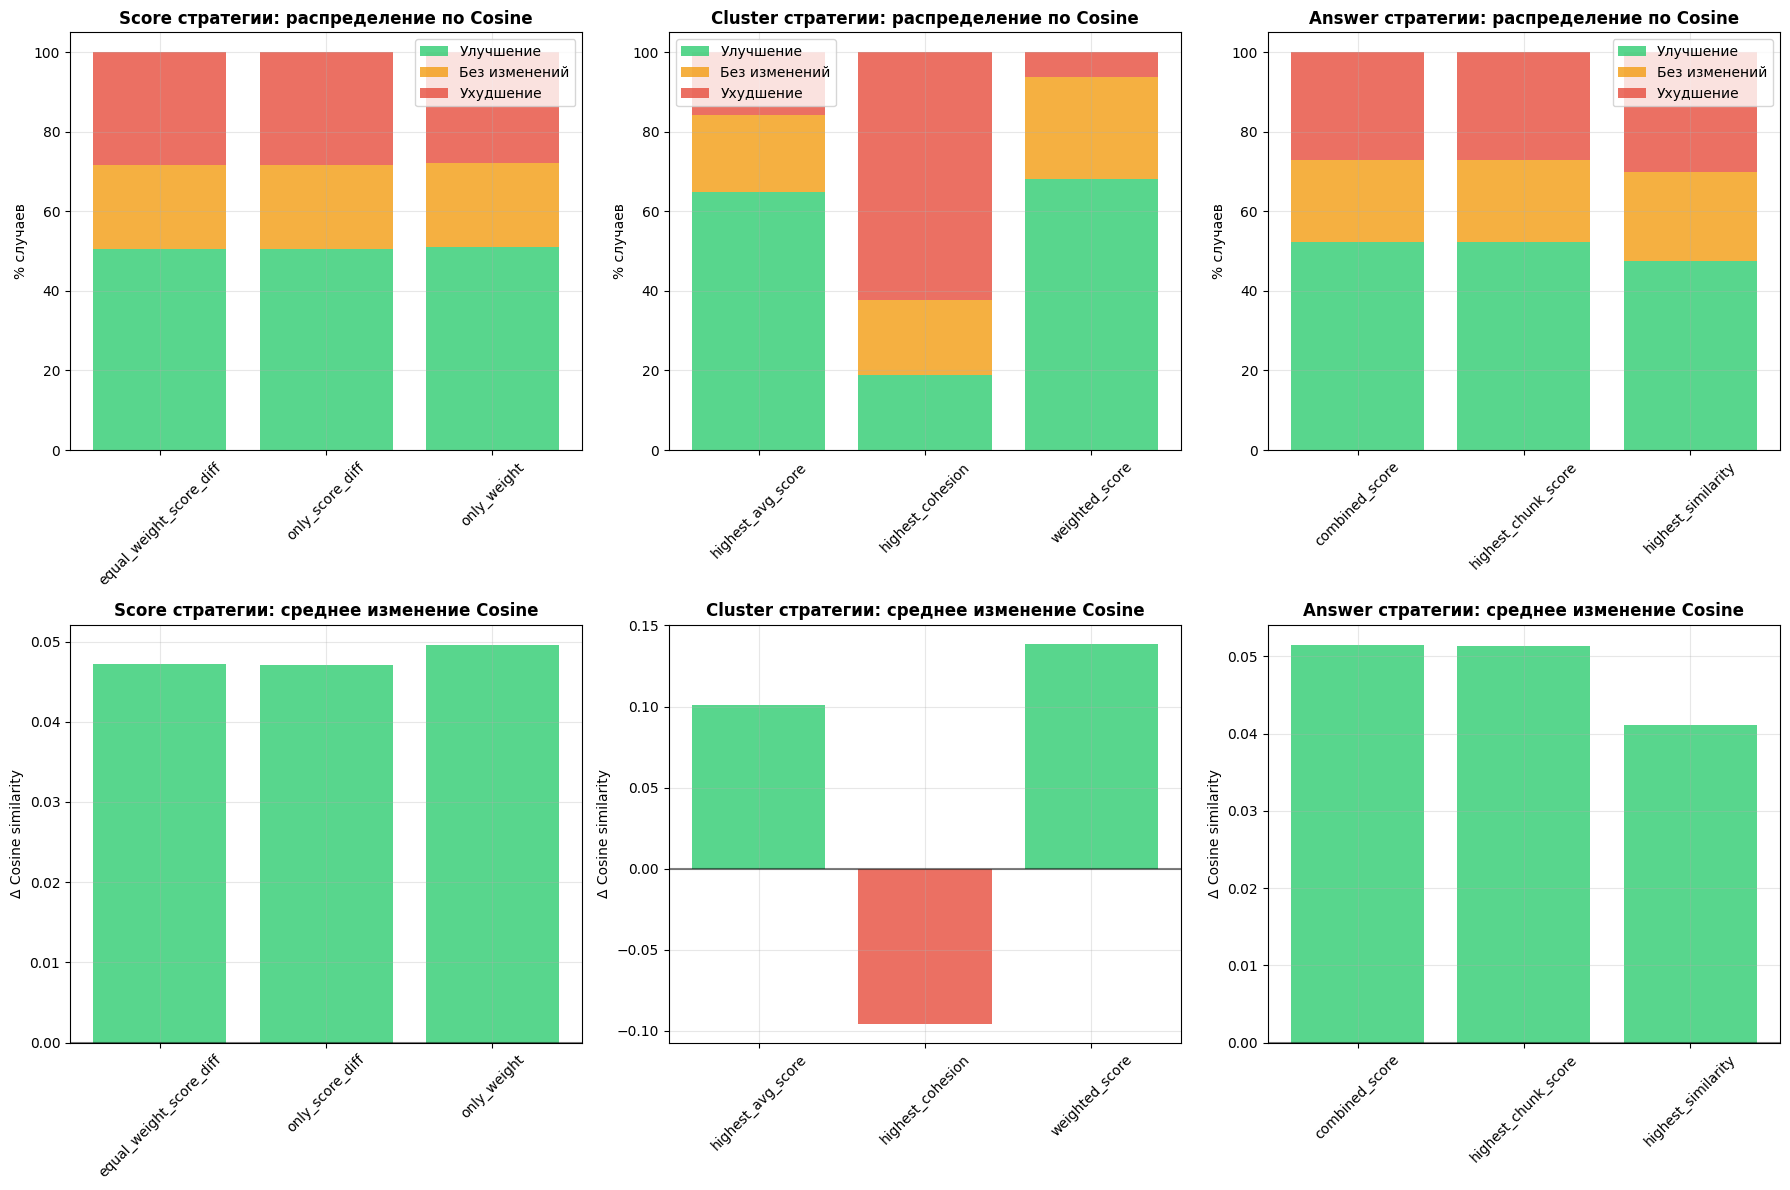


АНАЛИЗ КОМБИНАЦИЙ СТРАТЕГИЙ ПО COSINE SIMILARITY
Топ-10 комбинаций стратегий по улучшению Cosine:
                                                                        cosine_improved_pct  \
score_chunk_strategy    choose_cluster_strategy choose_answer_strategy                        
equal_weight_score_diff weighted_score          combined_score                        70.82   
                                                highest_chunk_score                   70.82   
only_score_diff         weighted_score          highest_chunk_score                   70.82   
only_weight             weighted_score          highest_chunk_score                   70.82   
                                                combined_score                        70.82   
only_score_diff         weighted_score          combined_score                        70.82   
only_weight             highest_avg_score       combined_score                        67.26   
                                              

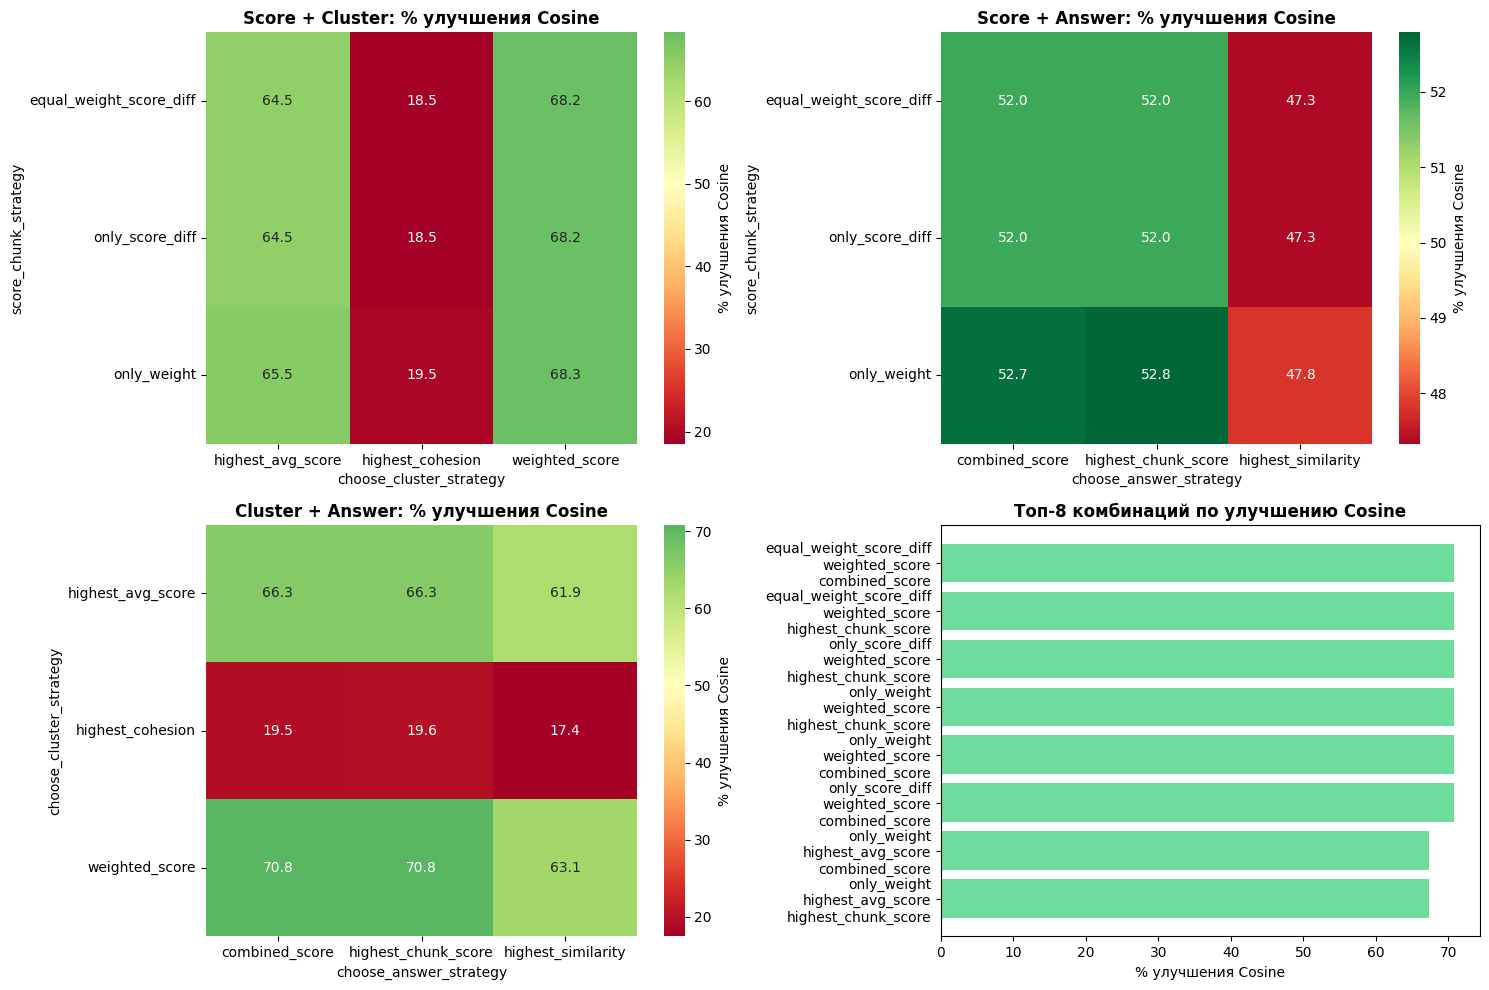


🎯 РЕКОМЕНДАЦИИ ПО СТРАТЕГИЯМ (Cosine Similarity):
Лучшая Score стратегия: only_weight (51.1% улучшений)
Лучшая Cluster стратегия: weighted_score (68.2% улучшений)
Лучшая Answer стратегия: highest_chunk_score (52.2% улучшений)

🏆 ОПТИМАЛЬНАЯ КОМБИНАЦИЯ ДЛЯ COSINE:
Score: equal_weight_score_diff
Cluster: weighted_score
Answer: combined_score
Результат: 70.8% улучшений Cosine
Среднее изменение: 0.1441
Количество примеров: 281.0

📊 ОБЩАЯ СТАТИСТИКА ПО COSINE SIMILARITY:
Среднее изменение: 0.0480
Стандартное отклонение: 0.2169
Максимальное улучшение: 0.6658
Максимальное ухудшение: -0.6786
Общий % улучшений: 50.6%
Общий % ухудшений: 28.2%
Общий % без изменений: 21.2%


In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import json

# Настройка стиля и цветовой схемы
plt.style.use('default')
sns.set_palette("husl")
COLORS = {'improved': '#2ecc71', 'unchanged': '#f39c12', 'worsened': '#e74c3c'}

# Функция для парсинга метрик
def parse_metrics(metrics_str):
    try:
        metrics = json.loads(metrics_str.replace("'", "\""))
        return metrics.get('cosine_sim', 0), metrics.get('lev_dist', 0)
    except:
        return 0, 0

# 1. Создаем копию исходного датафрейма и парсим метрики
analysis_df = res_done_df.copy()

# Парсим метрики
cosine_sim_base = []
cosine_sim_corrected = []

for idx, row in analysis_df.iterrows():
    cos_base, _ = parse_metrics(row['base_metrics'])
    cos_corr, _ = parse_metrics(row['corrected_metrics'])
    
    cosine_sim_base.append(cos_base)
    cosine_sim_corrected.append(cos_corr)

# Добавляем распарсенные метрики в датафрейм
analysis_df['cosine_sim_base'] = cosine_sim_base
analysis_df['cosine_sim_corrected'] = cosine_sim_corrected

# Вычисляем разницу только для cosine similarity
analysis_df['cosine_sim_diff'] = analysis_df['cosine_sim_corrected'] - analysis_df['cosine_sim_base']

# Определяем улучшения/ухудшения только по cosine
analysis_df['cosine_improved'] = analysis_df['cosine_sim_diff'] > 0
analysis_df['cosine_worsened'] = analysis_df['cosine_sim_diff'] < 0
analysis_df['cosine_unchanged'] = analysis_df['cosine_sim_diff'] == 0

# 2. Анализ эффективности отдельных стратегий (ТОЛЬКО COSINE)
print("АНАЛИЗ ЭФФЕКТИВНОСТИ СТРАТЕГИЙ ПО COSINE SIMILARITY")
print("=" * 60)

# Score стратегии
score_stats = analysis_df.groupby('score_chunk_strategy').agg({
    'cosine_improved': 'mean',
    'cosine_worsened': 'mean', 
    'cosine_unchanged': 'mean',
    'cosine_sim_diff': ['mean', 'std']
}).round(4)

score_stats.columns = ['cosine_improved_pct', 'cosine_worsened_pct', 'cosine_unchanged_pct', 
                      'cosine_mean_diff', 'cosine_std_diff']

# Переводим в проценты
for col in ['cosine_improved_pct', 'cosine_worsened_pct', 'cosine_unchanged_pct']:
    score_stats[col] = score_stats[col] * 100

print("\nScore стратегии:")
print(score_stats)

# Cluster стратегии
cluster_stats = analysis_df.groupby('choose_cluster_strategy').agg({
    'cosine_improved': 'mean',
    'cosine_worsened': 'mean',
    'cosine_unchanged': 'mean',
    'cosine_sim_diff': ['mean', 'std']
}).round(4)

cluster_stats.columns = ['cosine_improved_pct', 'cosine_worsened_pct', 'cosine_unchanged_pct', 
                        'cosine_mean_diff', 'cosine_std_diff']

for col in ['cosine_improved_pct', 'cosine_worsened_pct', 'cosine_unchanged_pct']:
    cluster_stats[col] = cluster_stats[col] * 100

print("\nCluster стратегии:")
print(cluster_stats)

# Answer стратегии
answer_stats = analysis_df.groupby('choose_answer_strategy').agg({
    'cosine_improved': 'mean',
    'cosine_worsened': 'mean',
    'cosine_unchanged': 'mean',
    'cosine_sim_diff': ['mean', 'std']
}).round(4)

answer_stats.columns = ['cosine_improved_pct', 'cosine_worsened_pct', 'cosine_unchanged_pct', 
                       'cosine_mean_diff', 'cosine_std_diff']

for col in ['cosine_improved_pct', 'cosine_worsened_pct', 'cosine_unchanged_pct']:
    answer_stats[col] = answer_stats[col] * 100

print("\nAnswer стратегии:")
print(answer_stats)

# 3. Визуализация эффективности стратегий (ТОЛЬКО COSINE)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Score стратегии - все состояния
score_all = score_stats[['cosine_improved_pct', 'cosine_worsened_pct', 'cosine_unchanged_pct']]
x_pos = np.arange(len(score_all))

axes[0,0].bar(x_pos, score_all['cosine_improved_pct'], 
              label='Улучшение', color=COLORS['improved'], alpha=0.8)
axes[0,0].bar(x_pos, score_all['cosine_unchanged_pct'], 
              bottom=score_all['cosine_improved_pct'],
              label='Без изменений', color=COLORS['unchanged'], alpha=0.8)
axes[0,0].bar(x_pos, score_all['cosine_worsened_pct'], 
              bottom=score_all['cosine_improved_pct'] + score_all['cosine_unchanged_pct'],
              label='Ухудшение', color=COLORS['worsened'], alpha=0.8)

axes[0,0].set_title('Score стратегии: распределение по Cosine', fontweight='bold')
axes[0,0].set_ylabel('% случаев')
axes[0,0].set_xticks(x_pos)
axes[0,0].set_xticklabels(score_all.index, rotation=45)
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Cluster стратегии - все состояния
cluster_all = cluster_stats[['cosine_improved_pct', 'cosine_worsened_pct', 'cosine_unchanged_pct']]
x_pos = np.arange(len(cluster_all))

axes[0,1].bar(x_pos, cluster_all['cosine_improved_pct'], 
              label='Улучшение', color=COLORS['improved'], alpha=0.8)
axes[0,1].bar(x_pos, cluster_all['cosine_unchanged_pct'], 
              bottom=cluster_all['cosine_improved_pct'],
              label='Без изменений', color=COLORS['unchanged'], alpha=0.8)
axes[0,1].bar(x_pos, cluster_all['cosine_worsened_pct'], 
              bottom=cluster_all['cosine_improved_pct'] + cluster_all['cosine_unchanged_pct'],
              label='Ухудшение', color=COLORS['worsened'], alpha=0.8)

axes[0,1].set_title('Cluster стратегии: распределение по Cosine', fontweight='bold')
axes[0,1].set_ylabel('% случаев')
axes[0,1].set_xticks(x_pos)
axes[0,1].set_xticklabels(cluster_all.index, rotation=45)
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Answer стратегии - все состояния
answer_all = answer_stats[['cosine_improved_pct', 'cosine_worsened_pct', 'cosine_unchanged_pct']]
x_pos = np.arange(len(answer_all))

axes[0,2].bar(x_pos, answer_all['cosine_improved_pct'], 
              label='Улучшение', color=COLORS['improved'], alpha=0.8)
axes[0,2].bar(x_pos, answer_all['cosine_unchanged_pct'], 
              bottom=answer_all['cosine_improved_pct'],
              label='Без изменений', color=COLORS['unchanged'], alpha=0.8)
axes[0,2].bar(x_pos, answer_all['cosine_worsened_pct'], 
              bottom=answer_all['cosine_improved_pct'] + answer_all['cosine_unchanged_pct'],
              label='Ухудшение', color=COLORS['worsened'], alpha=0.8)

axes[0,2].set_title('Answer стратегии: распределение по Cosine', fontweight='bold')
axes[0,2].set_ylabel('% случаев')
axes[0,2].set_xticks(x_pos)
axes[0,2].set_xticklabels(answer_all.index, rotation=45)
axes[0,2].legend()
axes[0,2].grid(True, alpha=0.3)

# Score стратегии - среднее изменение
axes[1,0].bar(score_stats.index, score_stats['cosine_mean_diff'], 
              color=[COLORS['improved'] if x > 0 else COLORS['worsened'] for x in score_stats['cosine_mean_diff']], 
              alpha=0.8)
axes[1,0].axhline(y=0, color='black', linestyle='-', alpha=0.5)
axes[1,0].set_title('Score стратегии: среднее изменение Cosine', fontweight='bold')
axes[1,0].set_ylabel('Δ Cosine similarity')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].grid(True, alpha=0.3)

# Cluster стратегии - среднее изменение
axes[1,1].bar(cluster_stats.index, cluster_stats['cosine_mean_diff'], 
              color=[COLORS['improved'] if x > 0 else COLORS['worsened'] for x in cluster_stats['cosine_mean_diff']], 
              alpha=0.8)
axes[1,1].axhline(y=0, color='black', linestyle='-', alpha=0.5)
axes[1,1].set_title('Cluster стратегии: среднее изменение Cosine', fontweight='bold')
axes[1,1].set_ylabel('Δ Cosine similarity')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].grid(True, alpha=0.3)

# Answer стратегии - среднее изменение
axes[1,2].bar(answer_stats.index, answer_stats['cosine_mean_diff'], 
              color=[COLORS['improved'] if x > 0 else COLORS['worsened'] for x in answer_stats['cosine_mean_diff']], 
              alpha=0.8)
axes[1,2].axhline(y=0, color='black', linestyle='-', alpha=0.5)
axes[1,2].set_title('Answer стратегии: среднее изменение Cosine', fontweight='bold')
axes[1,2].set_ylabel('Δ Cosine similarity')
axes[1,2].tick_params(axis='x', rotation=45)
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Анализ комбинаций стратегий (ТОЛЬКО COSINE)
print("\nАНАЛИЗ КОМБИНАЦИЙ СТРАТЕГИЙ ПО COSINE SIMILARITY")
print("=" * 60)

# Группируем по всем трем стратегиям
combo_stats = analysis_df.groupby(['score_chunk_strategy', 'choose_cluster_strategy', 'choose_answer_strategy']).agg({
    'cosine_improved': ['mean', 'count'],
    'cosine_sim_diff': 'mean'
}).round(4)

combo_stats.columns = ['cosine_improved_pct', 'count', 'cosine_mean_diff']

# Переводим в проценты
combo_stats['cosine_improved_pct'] = combo_stats['cosine_improved_pct'] * 100

# Сортируем по эффективности
combo_stats_sorted = combo_stats.sort_values('cosine_improved_pct', ascending=False)

print("Топ-10 комбинаций стратегий по улучшению Cosine:")
print(combo_stats_sorted.head(10))

# 5. Визуализация комбинаций стратегий (ТОЛЬКО COSINE)
plt.figure(figsize=(15, 10))

# Heatmap: Score + Cluster стратегии
plt.subplot(2, 2, 1)
score_cluster_combo = analysis_df.groupby(['score_chunk_strategy', 'choose_cluster_strategy'])['cosine_improved'].mean().unstack()
sns.heatmap(score_cluster_combo * 100, annot=True, fmt='.1f', cmap='RdYlGn', 
            center=50, cbar_kws={'label': '% улучшения Cosine'})
plt.title('Score + Cluster: % улучшения Cosine', fontweight='bold')

# Heatmap: Score + Answer стратегии
plt.subplot(2, 2, 2)
score_answer_combo = analysis_df.groupby(['score_chunk_strategy', 'choose_answer_strategy'])['cosine_improved'].mean().unstack()
sns.heatmap(score_answer_combo * 100, annot=True, fmt='.1f', cmap='RdYlGn', 
            center=50, cbar_kws={'label': '% улучшения Cosine'})
plt.title('Score + Answer: % улучшения Cosine', fontweight='bold')

# Heatmap: Cluster + Answer стратегии
plt.subplot(2, 2, 3)
cluster_answer_combo = analysis_df.groupby(['choose_cluster_strategy', 'choose_answer_strategy'])['cosine_improved'].mean().unstack()
sns.heatmap(cluster_answer_combo * 100, annot=True, fmt='.1f', cmap='RdYlGn', 
            center=50, cbar_kws={'label': '% улучшения Cosine'})
plt.title('Cluster + Answer: % улучшения Cosine', fontweight='bold')

# Лучшие комбинации по улучшению Cosine
plt.subplot(2, 2, 4)
top_combinations = combo_stats_sorted.head(8)
combination_names = [f"{idx[0]}\n{idx[1]}\n{idx[2]}" for idx in top_combinations.index]

plt.barh(range(len(combination_names)), top_combinations['cosine_improved_pct'], 
         color=COLORS['improved'], alpha=0.7)
plt.yticks(range(len(combination_names)), combination_names)
plt.xlabel('% улучшения Cosine')
plt.title('Топ-8 комбинаций по улучшению Cosine', fontweight='bold')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

# 6. Рекомендации (ТОЛЬКО COSINE)
print("\n🎯 РЕКОМЕНДАЦИИ ПО СТРАТЕГИЯМ (Cosine Similarity):")
print(f"Лучшая Score стратегия: {score_stats['cosine_improved_pct'].idxmax()} ({score_stats['cosine_improved_pct'].max():.1f}% улучшений)")
print(f"Лучшая Cluster стратегия: {cluster_stats['cosine_improved_pct'].idxmax()} ({cluster_stats['cosine_improved_pct'].max():.1f}% улучшений)")
print(f"Лучшая Answer стратегия: {answer_stats['cosine_improved_pct'].idxmax()} ({answer_stats['cosine_improved_pct'].max():.1f}% улучшений)")

best_combo = combo_stats_sorted.iloc[0]
best_combo_name = combo_stats_sorted.index[0]
print(f"\n🏆 ОПТИМАЛЬНАЯ КОМБИНАЦИЯ ДЛЯ COSINE:")
print(f"Score: {best_combo_name[0]}")
print(f"Cluster: {best_combo_name[1]}")
print(f"Answer: {best_combo_name[2]}")
print(f"Результат: {best_combo['cosine_improved_pct']:.1f}% улучшений Cosine")
print(f"Среднее изменение: {best_combo['cosine_mean_diff']:.4f}")
print(f"Количество примеров: {best_combo['count']}")

# Дополнительный анализ: статистика по величине изменений
print(f"\n📊 ОБЩАЯ СТАТИСТИКА ПО COSINE SIMILARITY:")
print(f"Среднее изменение: {analysis_df['cosine_sim_diff'].mean():.4f}")
print(f"Стандартное отклонение: {analysis_df['cosine_sim_diff'].std():.4f}")
print(f"Максимальное улучшение: {analysis_df['cosine_sim_diff'].max():.4f}")
print(f"Максимальное ухудшение: {analysis_df['cosine_sim_diff'].min():.4f}")
print(f"Общий % улучшений: {analysis_df['cosine_improved'].mean() * 100:.1f}%")
print(f"Общий % ухудшений: {analysis_df['cosine_worsened'].mean() * 100:.1f}%")
print(f"Общий % без изменений: {analysis_df['cosine_unchanged'].mean() * 100:.1f}%")

Оптимальная комбинация: equal_weight_score_diff + weighted_score + combined_score
Количество примеров: 281
Общий % улучшений Cosine: 70.8%
Среднее изменение Cosine: 0.1441


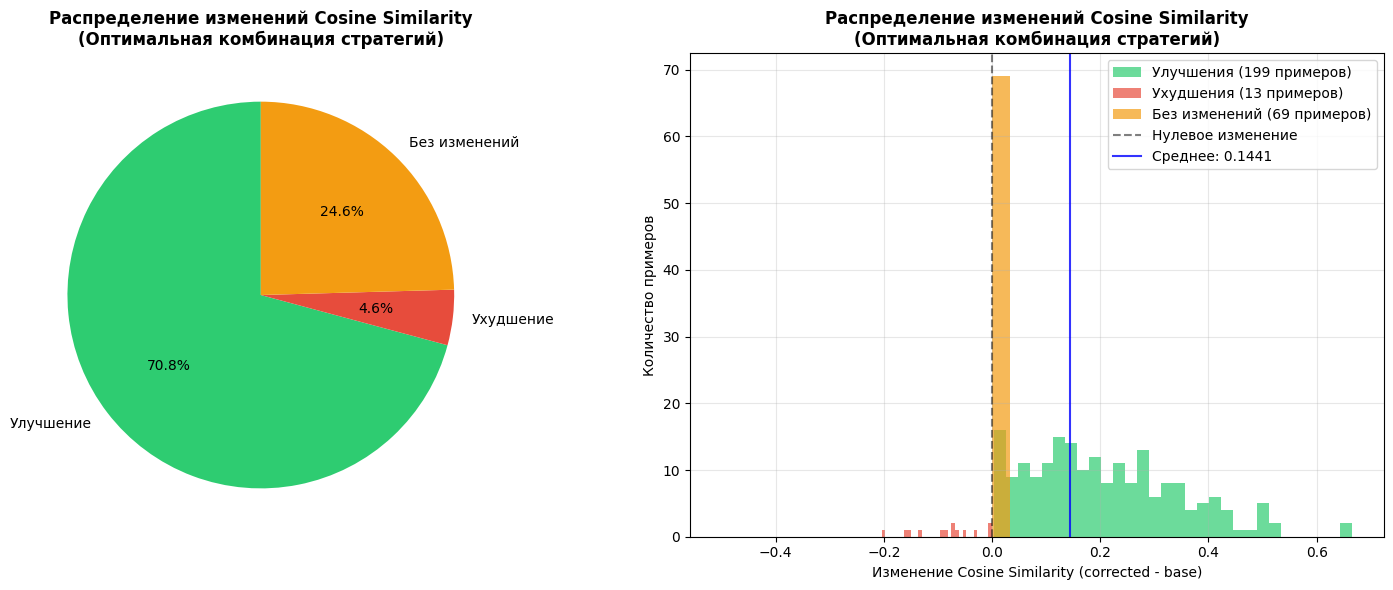


📊 ДЕТАЛЬНАЯ СТАТИСТИКА ОПТИМАЛЬНОЙ КОМБИНАЦИИ:
Общее количество примеров: 281
Количество улучшений: 199 (70.8%)
Количество ухудшений: 13 (4.6%)
Количество без изменений: 69 (24.6%)

Статистики изменений Cosine Similarity:
Среднее изменение: 0.144139
Медиана изменений: 0.118897
Стандартное отклонение: 0.156899
Минимальное изменение: -0.204074
Максимальное изменение: 0.665778
25-й перцентиль: 0.000000
75-й перцентиль: 0.258889


/tmp/ipykernel_3228624/3147005658.py:87: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(boxplot_data, labels=['Улучшения', 'Ухудшения', 'Без изменений'],


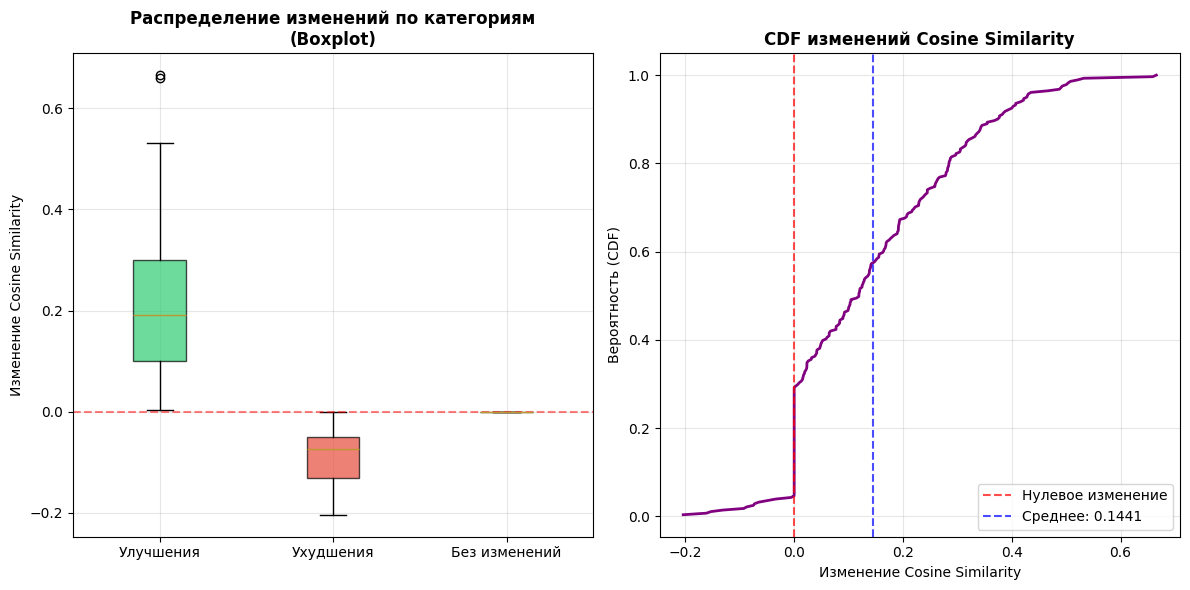


📈 АНАЛИЗ ВЕЛИЧИНЫ ИЗМЕНЕНИЙ:
Среднее улучшение: 0.209218
Максимальное улучшение: 0.665778
Минимальное улучшение: 0.003061
Среднее ухудшение: -0.087035
Максимальное ухудшение: -0.000206
Минимальное ухудшение: -0.204074

📊 СРАВНЕНИЕ С ОБЩИМИ РЕЗУЛЬТАТАМИ:
Общий % улучшений (все данные): 50.6%
Оптимальная комбинация % улучшений: 70.8%
Преимущество оптимальной комбинации: +20.2%

Общее среднее изменение: 0.047973
Оптимальная комбинация среднее изменение: 0.144139
Преимущество по среднему изменению: +0.096166


In [22]:
# Фильтруем данные для оптимальной комбинации
optimal_mask = (
    (analysis_df['score_chunk_strategy'] == 'equal_weight_score_diff') & 
    (analysis_df['choose_cluster_strategy'] == 'weighted_score') & 
    (analysis_df['choose_answer_strategy'] == 'combined_score')
)

optimal_data = analysis_df[optimal_mask]

print(f"Оптимальная комбинация: equal_weight_score_diff + weighted_score + combined_score")
print(f"Количество примеров: {len(optimal_data)}")
print(f"Общий % улучшений Cosine: {optimal_data['cosine_improved'].mean() * 100:.1f}%")
print(f"Среднее изменение Cosine: {optimal_data['cosine_sim_diff'].mean():.4f}")

# 1. Круговая диаграмма распределения изменений
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
categories = ['Улучшение', 'Ухудшение', 'Без изменений']
values = [
    optimal_data['cosine_improved'].mean() * 100,
    optimal_data['cosine_worsened'].mean() * 100,
    optimal_data['cosine_unchanged'].mean() * 100
]
colors = [COLORS['improved'], COLORS['worsened'], COLORS['unchanged']]

plt.pie(values, labels=categories, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Распределение изменений Cosine Similarity\n(Оптимальная комбинация стратегий)', 
          fontweight='bold', fontsize=12)

# 2. Гистограмма распределения изменений
plt.subplot(1, 2, 2)

# Разделяем данные на улучшения и ухудшения для цветовой кодировки
improved_data = optimal_data[optimal_data['cosine_improved']]['cosine_sim_diff']
worsened_data = optimal_data[optimal_data['cosine_worsened']]['cosine_sim_diff']
unchanged_data = optimal_data[optimal_data['cosine_unchanged']]['cosine_sim_diff']

# Строим гистограмму с разными цветами
plt.hist(improved_data, bins=30, alpha=0.7, color=COLORS['improved'], 
         label=f'Улучшения ({len(improved_data)} примеров)')
plt.hist(worsened_data, bins=30, alpha=0.7, color=COLORS['worsened'], 
         label=f'Ухудшения ({len(worsened_data)} примеров)')
plt.hist(unchanged_data, bins=30, alpha=0.7, color=COLORS['unchanged'], 
         label=f'Без изменений ({len(unchanged_data)} примеров)')

plt.axvline(x=0, color='black', linestyle='--', alpha=0.5, label='Нулевое изменение')
plt.axvline(x=optimal_data['cosine_sim_diff'].mean(), color='blue', 
            linestyle='-', alpha=0.8, label=f'Среднее: {optimal_data["cosine_sim_diff"].mean():.4f}')

plt.xlabel('Изменение Cosine Similarity (corrected - base)')
plt.ylabel('Количество примеров')
plt.title('Распределение изменений Cosine Similarity\n(Оптимальная комбинация стратегий)', 
          fontweight='bold', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Детальная статистика по оптимальной комбинации
print("\n📊 ДЕТАЛЬНАЯ СТАТИСТИКА ОПТИМАЛЬНОЙ КОМБИНАЦИИ:")
print(f"Общее количество примеров: {len(optimal_data)}")
print(f"Количество улучшений: {optimal_data['cosine_improved'].sum()} ({optimal_data['cosine_improved'].mean() * 100:.1f}%)")
print(f"Количество ухудшений: {optimal_data['cosine_worsened'].sum()} ({optimal_data['cosine_worsened'].mean() * 100:.1f}%)")
print(f"Количество без изменений: {optimal_data['cosine_unchanged'].sum()} ({optimal_data['cosine_unchanged'].mean() * 100:.1f}%)")
print(f"\nСтатистики изменений Cosine Similarity:")
print(f"Среднее изменение: {optimal_data['cosine_sim_diff'].mean():.6f}")
print(f"Медиана изменений: {optimal_data['cosine_sim_diff'].median():.6f}")
print(f"Стандартное отклонение: {optimal_data['cosine_sim_diff'].std():.6f}")
print(f"Минимальное изменение: {optimal_data['cosine_sim_diff'].min():.6f}")
print(f"Максимальное изменение: {optimal_data['cosine_sim_diff'].max():.6f}")
print(f"25-й перцентиль: {optimal_data['cosine_sim_diff'].quantile(0.25):.6f}")
print(f"75-й перцентиль: {optimal_data['cosine_sim_diff'].quantile(0.75):.6f}")

# 4. Boxplot для визуализации распределения изменений
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
# Создаем данные для boxplot с разделением по категориям
boxplot_data = [
    improved_data.values,
    worsened_data.values,
    unchanged_data.values
]

box = plt.boxplot(boxplot_data, labels=['Улучшения', 'Ухудшения', 'Без изменений'], 
                  patch_artist=True)

# Раскрашиваем boxplot
colors_box = [COLORS['improved'], COLORS['worsened'], COLORS['unchanged']]
for patch, color in zip(box['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.ylabel('Изменение Cosine Similarity')
plt.title('Распределение изменений по категориям\n(Boxplot)', fontweight='bold')
plt.grid(True, alpha=0.3)

# 5. Cumulative Distribution Function (CDF)
plt.subplot(1, 2, 2)
sorted_diff = np.sort(optimal_data['cosine_sim_diff'])
cdf = np.arange(1, len(sorted_diff) + 1) / len(sorted_diff)

plt.plot(sorted_diff, cdf, linewidth=2, color='purple')
plt.axvline(x=0, color='red', linestyle='--', alpha=0.7, label='Нулевое изменение')
plt.axvline(x=optimal_data['cosine_sim_diff'].mean(), color='blue', 
            linestyle='--', alpha=0.7, label=f'Среднее: {optimal_data["cosine_sim_diff"].mean():.4f}')

plt.xlabel('Изменение Cosine Similarity')
plt.ylabel('Вероятность (CDF)')
plt.title('CDF изменений Cosine Similarity', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 6. Анализ величины улучшений и ухудшений
print("\n📈 АНАЛИЗ ВЕЛИЧИНЫ ИЗМЕНЕНИЙ:")
if len(improved_data) > 0:
    print(f"Среднее улучшение: {improved_data.mean():.6f}")
    print(f"Максимальное улучшение: {improved_data.max():.6f}")
    print(f"Минимальное улучшение: {improved_data.min():.6f}")

if len(worsened_data) > 0:
    print(f"Среднее ухудшение: {worsened_data.mean():.6f}")
    print(f"Максимальное ухудшение: {worsened_data.max():.6f}")
    print(f"Минимальное ухудшение: {worsened_data.min():.6f}")

# 7. Сравнение с общими результатами
print(f"\n📊 СРАВНЕНИЕ С ОБЩИМИ РЕЗУЛЬТАТАМИ:")
print(f"Общий % улучшений (все данные): {analysis_df['cosine_improved'].mean() * 100:.1f}%")
print(f"Оптимальная комбинация % улучшений: {optimal_data['cosine_improved'].mean() * 100:.1f}%")
improvement_boost = (optimal_data['cosine_improved'].mean() - analysis_df['cosine_improved'].mean()) * 100
print(f"Преимущество оптимальной комбинации: {improvement_boost:+.1f}%")

print(f"\nОбщее среднее изменение: {analysis_df['cosine_sim_diff'].mean():.6f}")
print(f"Оптимальная комбинация среднее изменение: {optimal_data['cosine_sim_diff'].mean():.6f}")
mean_improvement = optimal_data['cosine_sim_diff'].mean() - analysis_df['cosine_sim_diff'].mean()
print(f"Преимущество по среднему изменению: {mean_improvement:+.6f}")

Оптимальная комбинация: only_weight + weighted_score + combined_score
Количество примеров: 281
Общий % улучшений Cosine: 70.8%
Среднее изменение Cosine: 0.1449


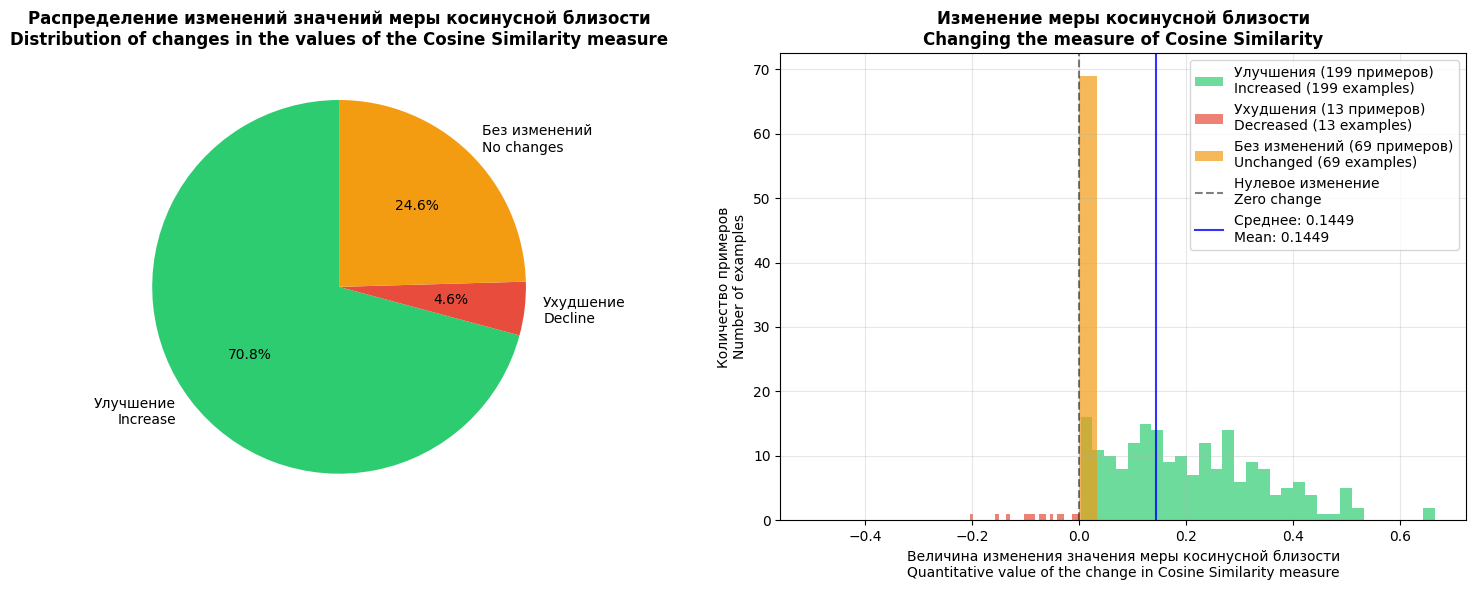


📊 ДЕТАЛЬНАЯ СТАТИСТИКА ОПТИМАЛЬНОЙ КОМБИНАЦИИ:
Общее количество примеров: 281
Количество улучшений: 199 (70.8%)
Количество ухудшений: 13 (4.6%)
Количество без изменений: 69 (24.6%)

Статистики изменений Cosine Similarity:
Среднее изменение: 0.144857
Медиана изменений: 0.118897
Стандартное отклонение: 0.156997
Минимальное изменение: -0.204074
Максимальное изменение: 0.665778
25-й перцентиль: 0.000000
75-й перцентиль: 0.261245


/tmp/ipykernel_3228624/476605480.py:88: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(boxplot_data, labels=['Улучшения\nIncrease', 'Ухудшения\nDecline'],


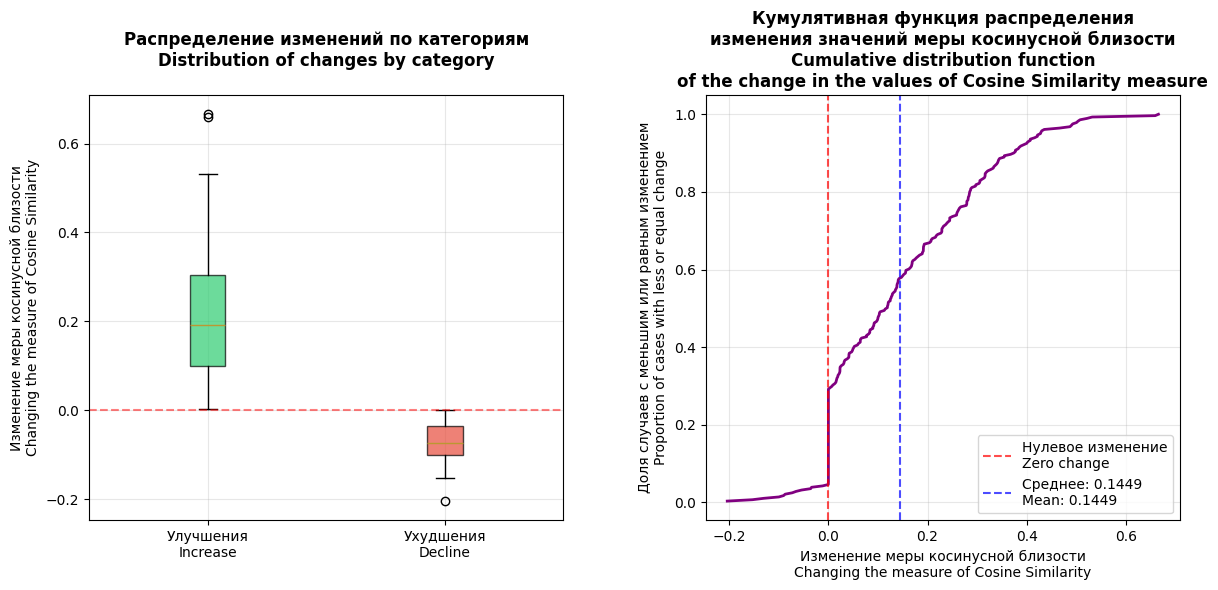


📈 АНАЛИЗ ВЕЛИЧИНЫ ИЗМЕНЕНИЙ:
Среднее улучшение: 0.209769
Максимальное улучшение: 0.665778
Минимальное улучшение: 0.003061
Среднее ухудшение: -0.079943
Максимальное ухудшение: -0.000206
Минимальное ухудшение: -0.204074

📊 СРАВНЕНИЕ С ОБЩИМИ РЕЗУЛЬТАТАМИ:
Общий % улучшений (все данные): 50.6%
Оптимальная комбинация % улучшений: 70.8%
Преимущество оптимальной комбинации: +20.2%

Общее среднее изменение: 0.047973
Оптимальная комбинация среднее изменение: 0.144857
Преимущество по среднему изменению: +0.096884


In [23]:
# Фильтруем данные для оптимальной комбинации
optimal_mask = (
    (analysis_df['score_chunk_strategy'] == 'only_weight') & 
    (analysis_df['choose_cluster_strategy'] == 'weighted_score') & 
    (analysis_df['choose_answer_strategy'] == 'combined_score')
)

optimal_data = analysis_df[optimal_mask]

print(f"Оптимальная комбинация: only_weight + weighted_score + combined_score")
print(f"Количество примеров: {len(optimal_data)}")
print(f"Общий % улучшений Cosine: {optimal_data['cosine_improved'].mean() * 100:.1f}%")
print(f"Среднее изменение Cosine: {optimal_data['cosine_sim_diff'].mean():.4f}")

# 1. Круговая диаграмма распределения изменений
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
categories = ['Улучшение\nIncrease', 'Ухудшение\nDecline', 'Без изменений\nNo changes']
values = [
    optimal_data['cosine_improved'].mean() * 100,
    optimal_data['cosine_worsened'].mean() * 100,
    optimal_data['cosine_unchanged'].mean() * 100
]
colors = [COLORS['improved'], COLORS['worsened'], COLORS['unchanged']]

plt.pie(values, labels=categories, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Распределение изменений значений меры косинусной близости\nDistribution of changes in the values ​​of the Cosine Similarity measure', 
          fontweight='bold', fontsize=12)

# 2. Гистограмма распределения изменений
plt.subplot(1, 2, 2)

# Разделяем данные на улучшения и ухудшения для цветовой кодировки
improved_data = optimal_data[optimal_data['cosine_improved']]['cosine_sim_diff']
worsened_data = optimal_data[optimal_data['cosine_worsened']]['cosine_sim_diff']
unchanged_data = optimal_data[optimal_data['cosine_unchanged']]['cosine_sim_diff']

# Строим гистограмму с разными цветами
plt.hist(improved_data, bins=30, alpha=0.7, color=COLORS['improved'], 
         label=f'Улучшения ({len(improved_data)} примеров)\nIncreased ({len(improved_data)} examples)')
plt.hist(worsened_data, bins=30, alpha=0.7, color=COLORS['worsened'], 
         label=f'Ухудшения ({len(worsened_data)} примеров)\nDecreased ({len(worsened_data)} examples)')
plt.hist(unchanged_data, bins=30, alpha=0.7, color=COLORS['unchanged'], 
         label=f'Без изменений ({len(unchanged_data)} примеров)\nUnchanged ({len(unchanged_data)} examples)')

plt.axvline(x=0, color='black', linestyle='--', alpha=0.5, label='Нулевое изменение\nZero change')
plt.axvline(x=optimal_data['cosine_sim_diff'].mean(), color='blue', 
            linestyle='-', alpha=0.8, label=f'Среднее: {optimal_data["cosine_sim_diff"].mean():.4f}\nMean: {optimal_data["cosine_sim_diff"].mean():.4f}')

plt.xlabel('Величина изменения значения меры косинусной близости\nQuantitative value of the change in Cosine Similarity measure')
plt.ylabel('Количество примеров\nNumber of examples')
plt.title('Изменение меры косинусной близости\nChanging the measure of Cosine Similarity', 
          fontweight='bold', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Детальная статистика по оптимальной комбинации
print("\n📊 ДЕТАЛЬНАЯ СТАТИСТИКА ОПТИМАЛЬНОЙ КОМБИНАЦИИ:")
print(f"Общее количество примеров: {len(optimal_data)}")
print(f"Количество улучшений: {optimal_data['cosine_improved'].sum()} ({optimal_data['cosine_improved'].mean() * 100:.1f}%)")
print(f"Количество ухудшений: {optimal_data['cosine_worsened'].sum()} ({optimal_data['cosine_worsened'].mean() * 100:.1f}%)")
print(f"Количество без изменений: {optimal_data['cosine_unchanged'].sum()} ({optimal_data['cosine_unchanged'].mean() * 100:.1f}%)")
print(f"\nСтатистики изменений Cosine Similarity:")
print(f"Среднее изменение: {optimal_data['cosine_sim_diff'].mean():.6f}")
print(f"Медиана изменений: {optimal_data['cosine_sim_diff'].median():.6f}")
print(f"Стандартное отклонение: {optimal_data['cosine_sim_diff'].std():.6f}")
print(f"Минимальное изменение: {optimal_data['cosine_sim_diff'].min():.6f}")
print(f"Максимальное изменение: {optimal_data['cosine_sim_diff'].max():.6f}")
print(f"25-й перцентиль: {optimal_data['cosine_sim_diff'].quantile(0.25):.6f}")
print(f"75-й перцентиль: {optimal_data['cosine_sim_diff'].quantile(0.75):.6f}")

# 4. Boxplot для визуализации распределения изменений
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
# Создаем данные для boxplot с разделением по категориям
boxplot_data = [
    improved_data.values,
    worsened_data.values,
    #unchanged_data.values
]
#box = plt.boxplot(boxplot_data, labels=['Улучшения\nIncrease', 'Ухудшения\nDecline', 'Без изменений\nNo changes'], 
#                  patch_artist=True)
box = plt.boxplot(boxplot_data, labels=['Улучшения\nIncrease', 'Ухудшения\nDecline'], 
                  patch_artist=True)

# Раскрашиваем boxplot
#colors_box = [COLORS['improved'], COLORS['worsened'], COLORS['unchanged']]
#for patch, color in zip(box['boxes'], colors_box):
#    patch.set_facecolor(color)
#    patch.set_alpha(0.7)

# Раскрашиваем boxplot
colors_box = [COLORS['improved'], COLORS['worsened']]
for patch, color in zip(box['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.ylabel('Изменение меры косинусной близости\nChanging the measure of Cosine Similarity')
plt.title('Распределение изменений по категориям\nDistribution of changes by category\n', fontweight='bold')
plt.grid(True, alpha=0.3)

# 5. Cumulative Distribution Function (CDF)
plt.subplot(1, 2, 2)
sorted_diff = np.sort(optimal_data['cosine_sim_diff'])
cdf = np.arange(1, len(sorted_diff) + 1) / len(sorted_diff)

plt.plot(sorted_diff, cdf, linewidth=2, color='purple')
plt.axvline(x=0, color='red', linestyle='--', alpha=0.7, label='Нулевое изменение\nZero change')
plt.axvline(x=optimal_data['cosine_sim_diff'].mean(), color='blue', 
            linestyle='--', alpha=0.7, label=f'Среднее: {optimal_data["cosine_sim_diff"].mean():.4f}\nMean: {optimal_data["cosine_sim_diff"].mean():.4f}')

plt.xlabel('Изменение меры косинусной близости\nChanging the measure of Cosine Similarity')
plt.ylabel('Доля случаев с меньшим или равным изменением\nProportion of cases with less or equal change')
plt.title('Кумулятивная функция распределения\nизменения значений меры косинусной близости\nCumulative distribution function\nof the change in the values ​​of Cosine Similarity measure', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

# 6. Анализ величины улучшений и ухудшений
print("\n📈 АНАЛИЗ ВЕЛИЧИНЫ ИЗМЕНЕНИЙ:")
if len(improved_data) > 0:
    print(f"Среднее улучшение: {improved_data.mean():.6f}")
    print(f"Максимальное улучшение: {improved_data.max():.6f}")
    print(f"Минимальное улучшение: {improved_data.min():.6f}")

if len(worsened_data) > 0:
    print(f"Среднее ухудшение: {worsened_data.mean():.6f}")
    print(f"Максимальное ухудшение: {worsened_data.max():.6f}")
    print(f"Минимальное ухудшение: {worsened_data.min():.6f}")

# 7. Сравнение с общими результатами
print(f"\n📊 СРАВНЕНИЕ С ОБЩИМИ РЕЗУЛЬТАТАМИ:")
print(f"Общий % улучшений (все данные): {analysis_df['cosine_improved'].mean() * 100:.1f}%")
print(f"Оптимальная комбинация % улучшений: {optimal_data['cosine_improved'].mean() * 100:.1f}%")
improvement_boost = (optimal_data['cosine_improved'].mean() - analysis_df['cosine_improved'].mean()) * 100
print(f"Преимущество оптимальной комбинации: {improvement_boost:+.1f}%")

print(f"\nОбщее среднее изменение: {analysis_df['cosine_sim_diff'].mean():.6f}")
print(f"Оптимальная комбинация среднее изменение: {optimal_data['cosine_sim_diff'].mean():.6f}")
mean_improvement = optimal_data['cosine_sim_diff'].mean() - analysis_df['cosine_sim_diff'].mean()
print(f"Преимущество по среднему изменению: {mean_improvement:+.6f}")

Оптимальная комбинация: only_weight + weighted_score + combined_score
Количество примеров: 281
Общий % улучшений Cosine: 70.8%
Среднее изменение Cosine: 0.1449


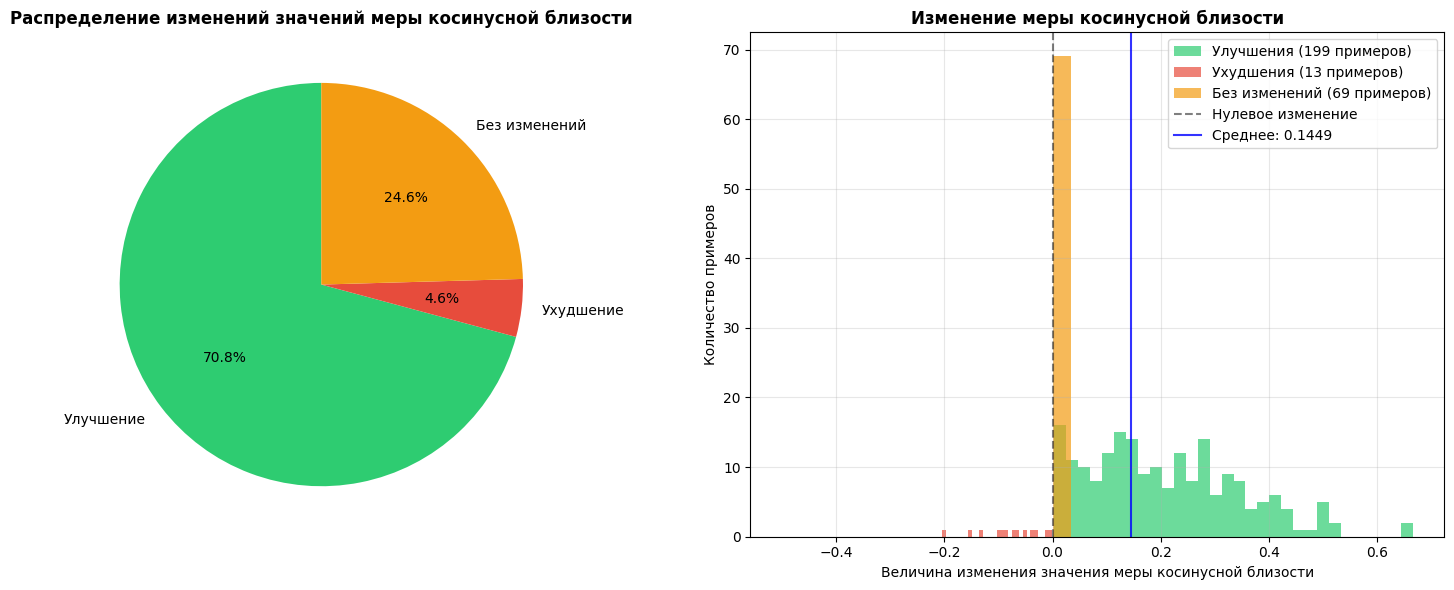


📊 ДЕТАЛЬНАЯ СТАТИСТИКА ОПТИМАЛЬНОЙ КОМБИНАЦИИ:
Общее количество примеров: 281
Количество улучшений: 199 (70.8%)
Количество ухудшений: 13 (4.6%)
Количество без изменений: 69 (24.6%)

Статистики изменений Cosine Similarity:
Среднее изменение: 0.144857
Медиана изменений: 0.118897
Стандартное отклонение: 0.156997
Минимальное изменение: -0.204074
Максимальное изменение: 0.665778
25-й перцентиль: 0.000000
75-й перцентиль: 0.261245


/tmp/ipykernel_3228624/4005317756.py:88: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(boxplot_data, labels=['Улучшения', 'Ухудшения'],


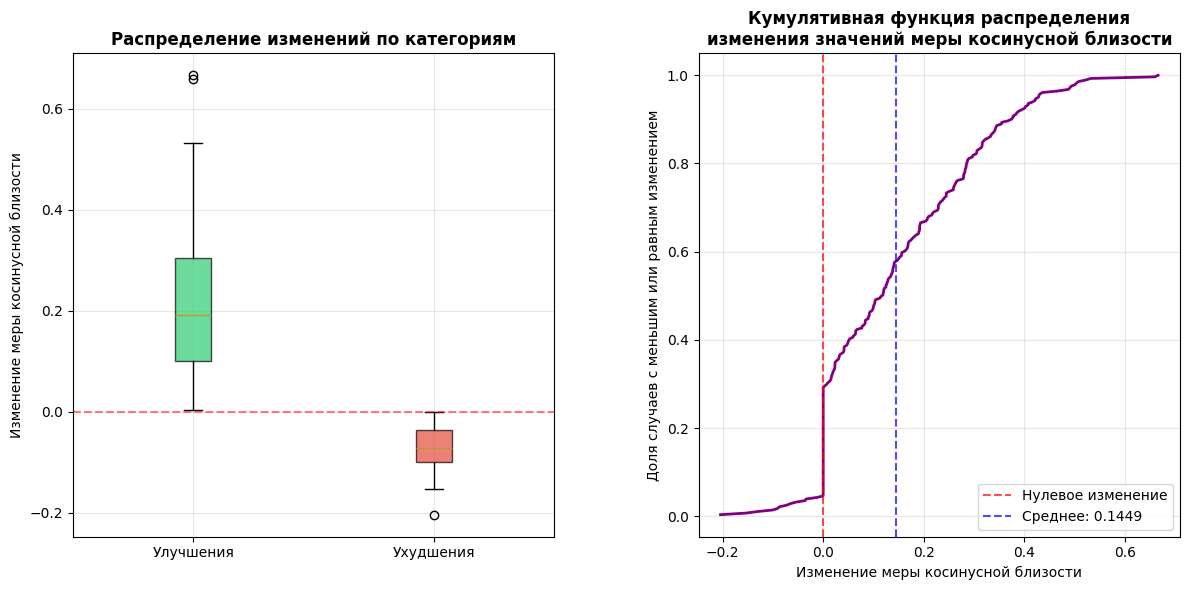


📈 АНАЛИЗ ВЕЛИЧИНЫ ИЗМЕНЕНИЙ:
Среднее улучшение: 0.209769
Максимальное улучшение: 0.665778
Минимальное улучшение: 0.003061
Среднее ухудшение: -0.079943
Максимальное ухудшение: -0.000206
Минимальное ухудшение: -0.204074

📊 СРАВНЕНИЕ С ОБЩИМИ РЕЗУЛЬТАТАМИ:
Общий % улучшений (все данные): 50.6%
Оптимальная комбинация % улучшений: 70.8%
Преимущество оптимальной комбинации: +20.2%

Общее среднее изменение: 0.047973
Оптимальная комбинация среднее изменение: 0.144857
Преимущество по среднему изменению: +0.096884


In [24]:
# Фильтруем данные для оптимальной комбинации
optimal_mask = (
    (analysis_df['score_chunk_strategy'] == 'only_weight') & 
    (analysis_df['choose_cluster_strategy'] == 'weighted_score') & 
    (analysis_df['choose_answer_strategy'] == 'combined_score')
)

optimal_data = analysis_df[optimal_mask]

print(f"Оптимальная комбинация: only_weight + weighted_score + combined_score")
print(f"Количество примеров: {len(optimal_data)}")
print(f"Общий % улучшений Cosine: {optimal_data['cosine_improved'].mean() * 100:.1f}%")
print(f"Среднее изменение Cosine: {optimal_data['cosine_sim_diff'].mean():.4f}")

# 1. Круговая диаграмма распределения изменений
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
categories = ['Улучшение', 'Ухудшение', 'Без изменений']
values = [
    optimal_data['cosine_improved'].mean() * 100,
    optimal_data['cosine_worsened'].mean() * 100,
    optimal_data['cosine_unchanged'].mean() * 100
]
colors = [COLORS['improved'], COLORS['worsened'], COLORS['unchanged']]

plt.pie(values, labels=categories, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Распределение изменений значений меры косинусной близости', 
          fontweight='bold', fontsize=12)

# 2. Гистограмма распределения изменений
plt.subplot(1, 2, 2)

# Разделяем данные на улучшения и ухудшения для цветовой кодировки
improved_data = optimal_data[optimal_data['cosine_improved']]['cosine_sim_diff']
worsened_data = optimal_data[optimal_data['cosine_worsened']]['cosine_sim_diff']
unchanged_data = optimal_data[optimal_data['cosine_unchanged']]['cosine_sim_diff']

# Строим гистограмму с разными цветами
plt.hist(improved_data, bins=30, alpha=0.7, color=COLORS['improved'], 
         label=f'Улучшения ({len(improved_data)} примеров)')
plt.hist(worsened_data, bins=30, alpha=0.7, color=COLORS['worsened'], 
         label=f'Ухудшения ({len(worsened_data)} примеров)')
plt.hist(unchanged_data, bins=30, alpha=0.7, color=COLORS['unchanged'], 
         label=f'Без изменений ({len(unchanged_data)} примеров)')

plt.axvline(x=0, color='black', linestyle='--', alpha=0.5, label='Нулевое изменение')
plt.axvline(x=optimal_data['cosine_sim_diff'].mean(), color='blue', 
            linestyle='-', alpha=0.8, label=f'Среднее: {optimal_data["cosine_sim_diff"].mean():.4f}')

plt.xlabel('Величина изменения значения меры косинусной близости')
plt.ylabel('Количество примеров')
plt.title('Изменение меры косинусной близости', 
          fontweight='bold', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Детальная статистика по оптимальной комбинации
print("\n📊 ДЕТАЛЬНАЯ СТАТИСТИКА ОПТИМАЛЬНОЙ КОМБИНАЦИИ:")
print(f"Общее количество примеров: {len(optimal_data)}")
print(f"Количество улучшений: {optimal_data['cosine_improved'].sum()} ({optimal_data['cosine_improved'].mean() * 100:.1f}%)")
print(f"Количество ухудшений: {optimal_data['cosine_worsened'].sum()} ({optimal_data['cosine_worsened'].mean() * 100:.1f}%)")
print(f"Количество без изменений: {optimal_data['cosine_unchanged'].sum()} ({optimal_data['cosine_unchanged'].mean() * 100:.1f}%)")
print(f"\nСтатистики изменений Cosine Similarity:")
print(f"Среднее изменение: {optimal_data['cosine_sim_diff'].mean():.6f}")
print(f"Медиана изменений: {optimal_data['cosine_sim_diff'].median():.6f}")
print(f"Стандартное отклонение: {optimal_data['cosine_sim_diff'].std():.6f}")
print(f"Минимальное изменение: {optimal_data['cosine_sim_diff'].min():.6f}")
print(f"Максимальное изменение: {optimal_data['cosine_sim_diff'].max():.6f}")
print(f"25-й перцентиль: {optimal_data['cosine_sim_diff'].quantile(0.25):.6f}")
print(f"75-й перцентиль: {optimal_data['cosine_sim_diff'].quantile(0.75):.6f}")

# 4. Boxplot для визуализации распределения изменений
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
# Создаем данные для boxplot с разделением по категориям
boxplot_data = [
    improved_data.values,
    worsened_data.values,
    #unchanged_data.values
]
#box = plt.boxplot(boxplot_data, labels=['Улучшения\nIncrease', 'Ухудшения\nDecline', 'Без изменений\nNo changes'], 
#                  patch_artist=True)
box = plt.boxplot(boxplot_data, labels=['Улучшения', 'Ухудшения'], 
                  patch_artist=True)

# Раскрашиваем boxplot
#colors_box = [COLORS['improved'], COLORS['worsened'], COLORS['unchanged']]
#for patch, color in zip(box['boxes'], colors_box):
#    patch.set_facecolor(color)
#    patch.set_alpha(0.7)

# Раскрашиваем boxplot
colors_box = [COLORS['improved'], COLORS['worsened']]
for patch, color in zip(box['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.ylabel('Изменение меры косинусной близости')
plt.title('Распределение изменений по категориям', fontweight='bold')
plt.grid(True, alpha=0.3)

# 5. Cumulative Distribution Function (CDF)
plt.subplot(1, 2, 2)
sorted_diff = np.sort(optimal_data['cosine_sim_diff'])
cdf = np.arange(1, len(sorted_diff) + 1) / len(sorted_diff)

plt.plot(sorted_diff, cdf, linewidth=2, color='purple')
plt.axvline(x=0, color='red', linestyle='--', alpha=0.7, label='Нулевое изменение')
plt.axvline(x=optimal_data['cosine_sim_diff'].mean(), color='blue', 
            linestyle='--', alpha=0.7, label=f'Среднее: {optimal_data["cosine_sim_diff"].mean():.4f}')

plt.xlabel('Изменение меры косинусной близости')
plt.ylabel('Доля случаев с меньшим или равным изменением')
plt.title('Кумулятивная функция распределения\nизменения значений меры косинусной близости', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

# 6. Анализ величины улучшений и ухудшений
print("\n📈 АНАЛИЗ ВЕЛИЧИНЫ ИЗМЕНЕНИЙ:")
if len(improved_data) > 0:
    print(f"Среднее улучшение: {improved_data.mean():.6f}")
    print(f"Максимальное улучшение: {improved_data.max():.6f}")
    print(f"Минимальное улучшение: {improved_data.min():.6f}")

if len(worsened_data) > 0:
    print(f"Среднее ухудшение: {worsened_data.mean():.6f}")
    print(f"Максимальное ухудшение: {worsened_data.max():.6f}")
    print(f"Минимальное ухудшение: {worsened_data.min():.6f}")

# 7. Сравнение с общими результатами
print(f"\n📊 СРАВНЕНИЕ С ОБЩИМИ РЕЗУЛЬТАТАМИ:")
print(f"Общий % улучшений (все данные): {analysis_df['cosine_improved'].mean() * 100:.1f}%")
print(f"Оптимальная комбинация % улучшений: {optimal_data['cosine_improved'].mean() * 100:.1f}%")
improvement_boost = (optimal_data['cosine_improved'].mean() - analysis_df['cosine_improved'].mean()) * 100
print(f"Преимущество оптимальной комбинации: {improvement_boost:+.1f}%")

print(f"\nОбщее среднее изменение: {analysis_df['cosine_sim_diff'].mean():.6f}")
print(f"Оптимальная комбинация среднее изменение: {optimal_data['cosine_sim_diff'].mean():.6f}")
mean_improvement = optimal_data['cosine_sim_diff'].mean() - analysis_df['cosine_sim_diff'].mean()
print(f"Преимущество по среднему изменению: {mean_improvement:+.6f}")

Оптимальная комбинация: only_weight + weighted_score + combined_score
Количество примеров: 281
Общий % улучшений Cosine: 70.8%
Среднее изменение Cosine: 0.1449


/tmp/ipykernel_3228624/3408669984.py:64: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(boxplot_data, labels=['Улучшения', 'Ухудшения'], patch_artist=True)


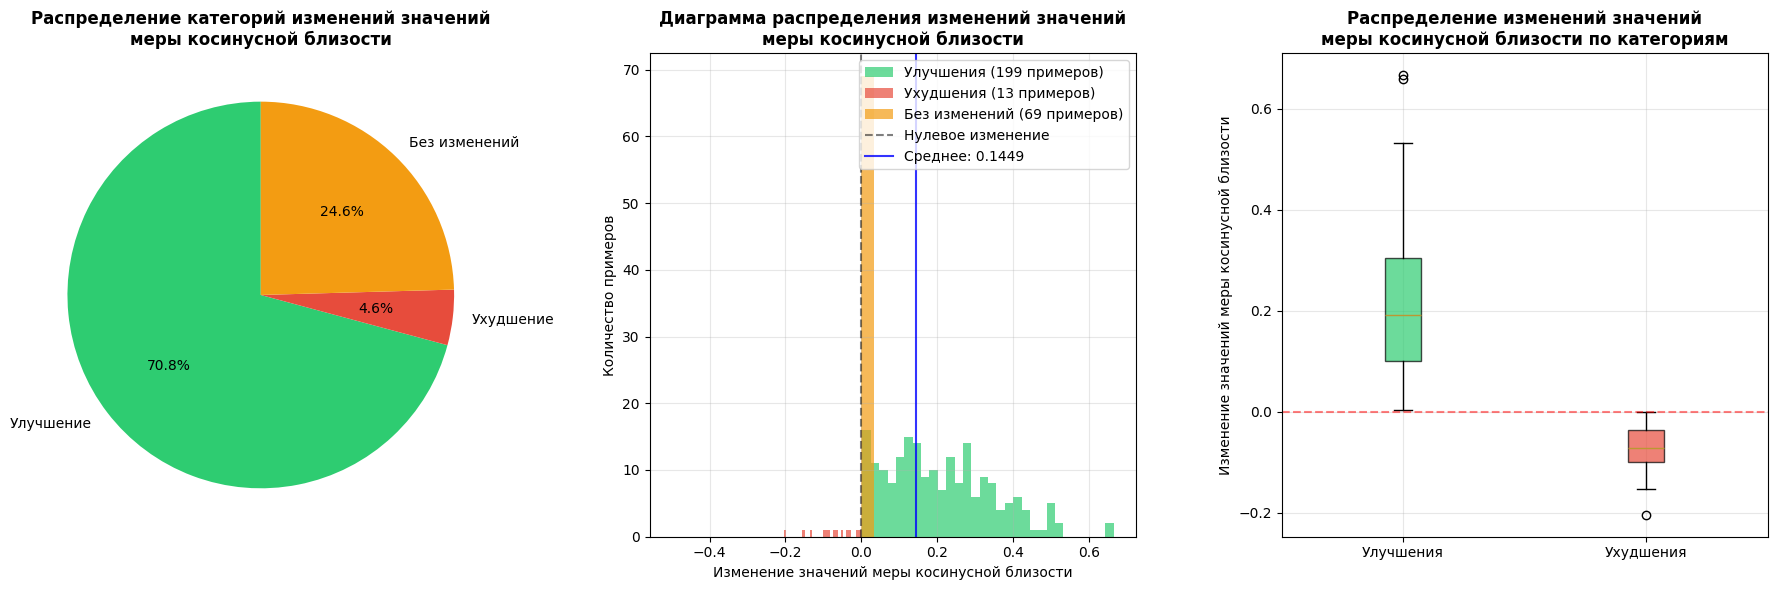

In [25]:
# Фильтруем данные для оптимальной комбинации
optimal_mask = (
    (analysis_df['score_chunk_strategy'] == 'only_weight') & 
    (analysis_df['choose_cluster_strategy'] == 'weighted_score') & 
    (analysis_df['choose_answer_strategy'] == 'combined_score')
)

optimal_data = analysis_df[optimal_mask]

print(f"Оптимальная комбинация: only_weight + weighted_score + combined_score")
print(f"Количество примеров: {len(optimal_data)}")
print(f"Общий % улучшений Cosine: {optimal_data['cosine_improved'].mean() * 100:.1f}%")
print(f"Среднее изменение Cosine: {optimal_data['cosine_sim_diff'].mean():.4f}")

# Размещаем все три графика на одном рисунке
plt.figure(figsize=(18, 6))

# 1. Круговая диаграмма распределения изменений
plt.subplot(1, 3, 1)
categories = ['Улучшение', 'Ухудшение', 'Без изменений']
values = [
    optimal_data['cosine_improved'].mean() * 100,
    optimal_data['cosine_worsened'].mean() * 100,
    optimal_data['cosine_unchanged'].mean() * 100
]
colors = [COLORS['improved'], COLORS['worsened'], COLORS['unchanged']]

plt.pie(values, labels=categories, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Распределение категорий изменений значений\nмеры косинусной близости', fontweight='bold', fontsize=12)

# 2. Гистограмма распределения изменений
plt.subplot(1, 3, 2)

# Разделяем данные на улучшения и ухудшения для цветовой кодировки
improved_data = optimal_data[optimal_data['cosine_improved']]['cosine_sim_diff']
worsened_data = optimal_data[optimal_data['cosine_worsened']]['cosine_sim_diff']
unchanged_data = optimal_data[optimal_data['cosine_unchanged']]['cosine_sim_diff']

# Строим гистограмму с разными цветами
plt.hist(improved_data, bins=30, alpha=0.7, color=COLORS['improved'], 
         label=f'Улучшения ({len(improved_data)} примеров)')
plt.hist(worsened_data, bins=30, alpha=0.7, color=COLORS['worsened'], 
         label=f'Ухудшения ({len(worsened_data)} примеров)')
plt.hist(unchanged_data, bins=30, alpha=0.7, color=COLORS['unchanged'], 
         label=f'Без изменений ({len(unchanged_data)} примеров)')

plt.axvline(x=0, color='black', linestyle='--', alpha=0.5, label='Нулевое изменение')
plt.axvline(x=optimal_data['cosine_sim_diff'].mean(), color='blue', 
            linestyle='-', alpha=0.8, label=f'Среднее: {optimal_data["cosine_sim_diff"].mean():.4f}')

plt.xlabel('Изменение значений меры косинусной близости')
plt.ylabel('Количество примеров')
plt.title('Диаграмма распределения изменений значений\nмеры косинусной близости', fontweight='bold', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# 3. Boxplot для визуализации распределения изменений
plt.subplot(1, 3, 3)
# Создаем данные для boxplot с разделением по категориям
boxplot_data = [
    improved_data.values,
    worsened_data.values,
]
box = plt.boxplot(boxplot_data, labels=['Улучшения', 'Ухудшения'], patch_artist=True)

# Раскрашиваем boxplot
colors_box = [COLORS['improved'], COLORS['worsened']]
for patch, color in zip(box['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.ylabel('Изменение значений меры косинусной близости')
plt.title('Распределение изменений значений\nмеры косинусной близости по категориям', fontweight='bold', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
plt.show()

In [26]:
import json
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import friedmanchisquare, wilcoxon, ttest_rel
from statsmodels.stats.multitest import multipletests
import scikit_posthocs as sp
from collections import defaultdict

# Функция для парсинга метрик (сохраняем вашу оригинальную функцию)
def parse_metrics(metrics_str):
    try:
        metrics = json.loads(metrics_str.replace("'", "\""))
        return metrics.get('cosine_sim', 0), metrics.get('lev_dist', 0)
    except:
        return 0, 0

# Словари для хранения результатов
results_summary = {}
detailed_analysis = {}
cosine_diff_data = {}  # Новый словарь для хранения изменений косинусной меры по стратегиям

# Анализируем каждую группу
for group_name, group_df in groups.items():
    print(f"\n{'='*60}")
    print(f"АНАЛИЗ ГРУППЫ: {group_name}")
    print(f"{'='*60}")
    
    # Парсим метрики
    cosine_sim_base = []
    lev_dist_base = []
    cosine_sim_corrected = []
    lev_dist_corrected = []
    cosine_sim_diff = []
    lev_dist_diff = []
    
    for idx, row in group_df.iterrows():
        try:
            # Парсим base_metrics
            cos_base, lev_base = parse_metrics(row['base_metrics'])
            cosine_sim_base.append(cos_base)
            lev_dist_base.append(lev_base)
            
            # Парсим corrected_metrics
            cos_corr, lev_corr = parse_metrics(row['corrected_metrics'])
            cosine_sim_corrected.append(cos_corr)
            lev_dist_corrected.append(lev_corr)
            
            # Вычисляем разницы
            cosine_sim_diff.append(cos_corr - cos_base)
            lev_dist_diff.append(lev_corr - lev_base)
            
        except Exception as e:
            print(f"Ошибка парсинга для строки {idx}: {e}")
            continue
    
    # Сохраняем изменения косинусной меры для статистических тестов
    cosine_diff_data[group_name] = cosine_sim_diff
    
    # Создаем DataFrame для анализа
    analysis_df = pd.DataFrame({
        'cosine_sim_base': cosine_sim_base,
        'cosine_sim_corrected': cosine_sim_corrected,
        'cosine_sim_diff': cosine_sim_diff,
        'lev_dist_base': lev_dist_base,
        'lev_dist_corrected': lev_dist_corrected,
        'lev_dist_diff': lev_dist_diff
    })
    
    # ... (остальной ваш код анализа остается без изменений)
    # [здесь ваш существующий код анализа улучшений/ухудшений]

# СТАТИСТИЧЕСКИЕ ТЕСТЫ ДЛЯ СРАВНЕНИЯ СТРАТЕГИЙ
print(f"\n{'='*80}")
print(f"СТАТИСТИЧЕСКИЕ ТЕСТЫ ДЛЯ СРАВНЕНИЯ СТРАТЕГИЙ")
print(f"{'='*80}")

# 1. Подготовка данных для статистических тестов
# Создаем DataFrame с изменениями косинусной меры для всех стратегий
cosine_diff_df = pd.DataFrame(cosine_diff_data)

# 2. Проверка нормальности распределения изменений для каждой стратегии
print("\n1. ПРОВЕРКА НОРМАЛЬНОСТИ РАСПРЕДЕЛЕНИЯ (Тест Шапиро-Уилка):")
normality_results = {}
for strategy in cosine_diff_df.columns:
    stat, p_value = stats.shapiro(cosine_diff_df[strategy].dropna())
    normality_results[strategy] = {'stat': stat, 'p_value': p_value}
    print(f"{strategy:50} W={stat:.4f}, p={p_value:.4f} {'(нормальное)' if p_value > 0.05 else '(не нормальное)'}")

# 3. Поскольку данные, вероятно, не нормальны, используем непараметрические тесты
print("\n2. ТЕСТ ФРИДМАНА (сравнение всех стратегий):")
# Удаляем строки с пропущенными значениями для теста Фридмана
friedman_data = [cosine_diff_df[col].dropna() for col in cosine_diff_df.columns]
# Берем только те строки, где есть данные для всех стратегий
min_len = min(len(data) for data in friedman_data)
friedman_data_balanced = [data[:min_len] for data in friedman_data]

friedman_stat, friedman_p = friedmanchisquare(*friedman_data_balanced)
print(f"Статистика Фридмана: χ²({len(cosine_diff_df.columns)-1}) = {friedman_stat:.10f}, p = {friedman_p:.10f}")

if friedman_p < 0.05:
    print("✓ Статистически значимые различия между стратегиями обнаружены")
    
    # 4. Пост-хок тест Неменьи для попарных сравнений
    print("\n3. ПОСТ-ХОК ТЕСТ НЕМЕНЬИ (попарные сравнения):")
    nemenyi_result = sp.posthoc_nemenyi_friedman(cosine_diff_df)
    
    # Находим статистически значимые попарные различия
    significant_pairs = []
    for i in range(len(nemenyi_result)):
        for j in range(i+1, len(nemenyi_result)):
            if nemenyi_result.iloc[i, j] < 0.05:
                significant_pairs.append((nemenyi_result.index[i], nemenyi_result.columns[j], nemenyi_result.iloc[i, j]))
    
    print(f"Найдено статистически значимых пар: {len(significant_pairs)}")
    for pair in significant_pairs[:10]:  # Показываем первые 10 пар
        print(f"  {pair[0]} vs {pair[1]}: p = {pair[2]:.4f}")
    
    if len(significant_pairs) > 10:
        print(f"  ... и еще {len(significant_pairs) - 10} пар")
else:
    print("✗ Статистически значимых различий между стратегиями не обнаружено")

# 5. Сравнение лучших стратегий с остальными
print("\n4. СРАВНЕНИЕ ЛУЧШИХ СТРАТЕГИЙ С ОСТАЛЬНЫМИ:")

# Находим лучшие стратегии по среднему изменению косинусной меры
mean_improvements = cosine_diff_df.mean().sort_values(ascending=False)
best_strategies = mean_improvements.head(3)  # Топ-3 стратегии

print("\nТоп-3 стратегии по среднему улучшению косинусной меры:")
for i, (strategy, improvement) in enumerate(best_strategies.items()):
    print(f"  {i+1}. {strategy}: {improvement:.4f}")

# Парные сравнения лучших стратегий с остальными с поправкой на множественное тестирование
print("\nПарные сравнения лучшей стратегии с альтернативами (тест Уилкоксона):")
best_strategy = best_strategies.index[0]
comparison_results = []

for strategy in cosine_diff_df.columns:
    if strategy != best_strategy:
        # Тест Уилкоксона для парных сравнений
        stat, p_value = wilcoxon(cosine_diff_df[best_strategy].dropna(), 
                                cosine_diff_df[strategy].dropna())
        comparison_results.append({
            'comparison': f"{best_strategy} vs {strategy}",
            'statistic': stat,
            'p_value': p_value,
            'mean_diff': mean_improvements[best_strategy] - mean_improvements[strategy]
        })

# Применяем поправку Бенджамини-Хохберга для множественных сравнений
p_values = [result['p_value'] for result in comparison_results]
rejected, corrected_p, _, _ = multipletests(p_values, method='fdr_bh')

# Выводим результаты с поправкой
print(f"\nРезультаты с поправкой Бенджамини-Хохберга:")
for i, result in enumerate(comparison_results):
    significance = "✓ СТАТИСТИЧЕСКИ ЗНАЧИМО" if corrected_p[i] < 0.05 else "✗ не значимо"
    print(f"  {result['comparison']}: W={result['statistic']:.2f}, p={result['p_value']:.4f}, "
          f"скорр. p={corrected_p[i]:.4f} ({significance})")

# 6. Расчет величины эффекта для значимых сравнений
print("\n5. ВЕЛИЧИНА ЭФФЕКТА ДЛЯ ЗНАЧИМЫХ СРАВНЕНИЙ:")

def cliffs_delta(x, y):
    """Вычисляет Cliff's Delta - непараметрическую величину эффекта"""
    n_x = len(x)
    n_y = len(y)
    count = 0
    for i in x:
        for j in y:
            if i > j:
                count += 1
            elif i < j:
                count -= 1
    return count / (n_x * n_y)

# Вычисляем Cliff's Delta для значимых сравнений
significant_comparisons = [(comparison_results[i], corrected_p[i]) 
                          for i in range(len(comparison_results)) 
                          if corrected_p[i] < 0.05]

for result, corrected_p in significant_comparisons:
    strategy1, strategy2 = result['comparison'].split(' vs ')
    delta = cliffs_delta(cosine_diff_df[strategy1].dropna(), 
                        cosine_diff_df[strategy2].dropna())
    effect_size = "малый" if abs(delta) < 0.33 else "средний" if abs(delta) < 0.474 else "большой"
    print(f"  {result['comparison']}: Cliff's δ = {delta:.3f} ({effect_size} эффект)")

# 7. Сводная таблица результатов
print(f"\n{'='*80}")
print(f"СВОДНАЯ СТАТИСТИКА ПО СТРАТЕГИЯМ")
print(f"{'='*80}")

summary_stats = pd.DataFrame({
    'mean_improvement': cosine_diff_df.mean(),
    'std_improvement': cosine_diff_df.std(),
    'median_improvement': cosine_diff_df.median(),
    'min_improvement': cosine_diff_df.min(),
    'max_improvement': cosine_diff_df.max(),
    'n_samples': cosine_diff_df.count()
}).sort_values('mean_improvement', ascending=False)

print(summary_stats.head(10))

# Сохранение результатов статистического анализа
stat_results = {
    'friedman_test': {'statistic': friedman_stat, 'p_value': friedman_p},
    'normality_tests': normality_results,
    'pairwise_comparisons': comparison_results,
    'corrected_p_values': corrected_p,
    'summary_statistics': summary_stats
}

print(f"\nРезультаты статистического анализа сохранены")


АНАЛИЗ ГРУППЫ: equal_weight_score_diff_highest_avg_score_combined_score

АНАЛИЗ ГРУППЫ: equal_weight_score_diff_highest_avg_score_highest_chunk_score

АНАЛИЗ ГРУППЫ: equal_weight_score_diff_highest_avg_score_highest_similarity

АНАЛИЗ ГРУППЫ: equal_weight_score_diff_highest_cohesion_combined_score

АНАЛИЗ ГРУППЫ: equal_weight_score_diff_highest_cohesion_highest_chunk_score

АНАЛИЗ ГРУППЫ: equal_weight_score_diff_highest_cohesion_highest_similarity

АНАЛИЗ ГРУППЫ: equal_weight_score_diff_weighted_score_combined_score

АНАЛИЗ ГРУППЫ: equal_weight_score_diff_weighted_score_highest_chunk_score

АНАЛИЗ ГРУППЫ: equal_weight_score_diff_weighted_score_highest_similarity

АНАЛИЗ ГРУППЫ: only_score_diff_highest_avg_score_combined_score

АНАЛИЗ ГРУППЫ: only_score_diff_highest_avg_score_highest_chunk_score

АНАЛИЗ ГРУППЫ: only_score_diff_highest_avg_score_highest_similarity

АНАЛИЗ ГРУППЫ: only_score_diff_highest_cohesion_combined_score

АНАЛИЗ ГРУППЫ: only_score_diff_highest_cohesion_highest_chu

In [27]:
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

def nonparametric_effect_size(data):
    """Непараметрическая оценка размера эффекта для теста Уилкоксона"""
    # r = Z/√N (стандартный подход для непараметрических тестов)
    n = len(data)
    stat, p_value = wilcoxon(data)
    # Аппроксимация Z-статистики из теста Уилкоксона
    z = stat / np.sqrt(n * (n + 1) * (2 * n + 1) / 6)
    r = abs(z) / np.sqrt(n)
    
    # Интерпретация размера эффекта
    if r < 0.1:
        effect_interpretation = "очень малый"
    elif r < 0.3:
        effect_interpretation = "малый"
    elif r < 0.5:
        effect_interpretation = "средний"
    else:
        effect_interpretation = "большой"
    
    return r, effect_interpretation

def practical_significance_metrics(data):
    """Практически значимые метрики"""
    positive_improvements = np.sum(data > 0)
    negative_improvements = np.sum(data < 0)
    zero_improvements = np.sum(data == 0)
    total = len(data)
    
    return {
        'percent_improved': (positive_improvements / total) * 100,
        'percent_worsened': (negative_improvements / total) * 100,
        'percent_unchanged': (zero_improvements / total) * 100,
        'median_improvement': np.median(data),
        'q25_improvement': np.percentile(data, 25),
        'q75_improvement': np.percentile(data, 75)
    }

print("АЛЬТЕРНАТИВНЫЙ ПОДХОД К СТАТИСТИЧЕСКОМУ АНАЛИЗУ")
print("=" * 60)

# 1. Тест Уилкоксона для каждой стратегии (сравнение с 0)
print("\n1. ТЕСТ УИЛКОКСОНА ДЛЯ КАЖДОЙ СТРАТЕГИИ:")
wilcoxon_results = []

for strategy in cosine_diff_df.columns:
    # Удаляем NaN значения
    data = cosine_diff_df[strategy].dropna()
    
    # Тест Уилкоксона (сравнение с медианой = 0)
    stat, p_value = wilcoxon(data, alternative='two-sided')
    
    # Непараметрическая оценка размера эффекта
    r_effect, effect_interpretation = nonparametric_effect_size(data)
    
    # Практически значимые метрики
    practical_metrics = practical_significance_metrics(data)
    
    wilcoxon_results.append({
        'strategy': strategy,
        'statistic': stat,
        'p_value': p_value,
        'effect_size_r': r_effect,
        'effect_interpretation': effect_interpretation,
        'mean_improvement': np.mean(data),
        'n_samples': len(data),
        **practical_metrics
    })

# Создаем DataFrame с результатами
wilcoxon_df = pd.DataFrame(wilcoxon_results)

# 2. Поправка на множественные сравнения (Бонферрони)
print("\n2. ПОПРАВКА НА МНОЖЕСТВЕННЫЕ СРАВНЕНИЯ:")
alpha = 0.05
alpha_corrected = alpha / len(wilcoxon_df)

# Применяем поправку Бонферрони
wilcoxon_df['p_value_bonferroni'] = wilcoxon_df['p_value'] * len(wilcoxon_df)
wilcoxon_df['significant_bonferroni'] = wilcoxon_df['p_value_bonferroni'] < alpha

# Поправка Бенджамини-Хохберга (FDR)
rejected_fdr, pvals_corrected, _, _ = multipletests(
    wilcoxon_df['p_value'], 
    alpha=alpha, 
    method='fdr_bh'
)
wilcoxon_df['p_value_fdr'] = pvals_corrected
wilcoxon_df['significant_fdr'] = rejected_fdr

# 3. Вывод результатов
print("\n3. РЕЗУЛЬТАТЫ СТАТИСТИЧЕСКОГО ТЕСТИРОВАНИЯ:")

# Сортируем по улучшению
wilcoxon_sorted = wilcoxon_df.sort_values('mean_improvement', ascending=False)

for i, row in wilcoxon_sorted.iterrows():
    significance_bonf = "✓" if row['significant_bonferroni'] else "✗"
    significance_fdr = "✓" if row['significant_fdr'] else "✗"
    
    print(f"\n{row['strategy']}:")
    print(f"  Среднее улучшение: {row['mean_improvement']:.4f}")
    print(f"  Медианное улучшение: {row['median_improvement']:.4f}")
    print(f"  p-value: {row['p_value']:.6f}")
    print(f"  p-value (Bonferroni): {row['p_value_bonferroni']:.6f} {significance_bonf}")
    print(f"  p-value (FDR): {row['p_value_fdr']:.6f} {significance_fdr}")
    print(f"  Размер эффекта (r): {row['effect_size_r']:.3f} ({row['effect_interpretation']})")
    print(f"  Улучшилось: {row['percent_improved']:.1f}%")
    print(f"  Ухудшилось: {row['percent_worsened']:.1f}%")
    print(f"  Без изменений: {row['percent_unchanged']:.1f}%")
    print(f"  IQR: [{row['q25_improvement']:.4f}, {row['q75_improvement']:.4f}]")

# 4. Сводная статистика
print(f"\n4. СВОДНАЯ СТАТИСТИКА:")
total_strategies = len(wilcoxon_df)
significant_bonf = wilcoxon_df['significant_bonferroni'].sum()
significant_fdr = wilcoxon_df['significant_fdr'].sum()

print(f"Всего стратегий: {total_strategies}")
print(f"Значимых по Бонферрони: {significant_bonf} ({significant_bonf/total_strategies*100:.1f}%)")
print(f"Значимых по FDR: {significant_fdr} ({significant_fdr/total_strategies*100:.1f}%)")

# Стратегии с большим/средним эффектом
medium_large_effect = wilcoxon_df[wilcoxon_df['effect_interpretation'].isin(['средний', 'большой'])]
print(f"Стратегий со средним/большим эффектом: {len(medium_large_effect)}")

# 5. Топ стратегии по практической значимости
print(f"\n5. ТОП-5 СТРАТЕГИЙ ПО ПРАКТИЧЕСКОЙ ЗНАЧИМОСТИ:")

# Критерии: значимость FDR + высокий процент улучшений + средний/большой эффект
top_strategies = wilcoxon_sorted[
    wilcoxon_sorted['significant_fdr'] & 
    (wilcoxon_sorted['effect_interpretation'].isin(['средний', 'большой'])) &
    (wilcoxon_sorted['percent_improved'] > 60)
].head(5)

for i, (idx, row) in enumerate(top_strategies.iterrows(), 1):
    print(f"{i}. {row['strategy']}")
    print(f"   Улучшение: {row['mean_improvement']:.4f} (медиана: {row['median_improvement']:.4f})")
    print(f"   Эффект: {row['effect_size_r']:.3f} ({row['effect_interpretation']})")
    print(f"   % улучшений: {row['percent_improved']:.1f}%")

# 6. Дополнительный анализ: согласованность метрик
print(f"\n6. АНАЛИЗ СОГЛАСОВАННОСТИ МЕТРИК:")

# Проверяем, насколько разные метрики дают согласованные результаты
high_improvement_rate = wilcoxon_df['percent_improved'] > 60
large_effect = wilcoxon_df['effect_interpretation'].isin(['средний', 'большой'])
statistically_significant = wilcoxon_df['significant_fdr']

# Считаем стратегии, удовлетворяющие всем трем критериям
all_criteria = high_improvement_rate & large_effect & statistically_significant
print(f"Стратегий, удовлетворяющих всем критериям: {all_criteria.sum()}")

print(f"\n{'='*60}")
print("ВЫВОД: Использование непараметрических метрик эффекта и практических")
print("показателей обеспечивает более надежную оценку значимости улучшений.")

АЛЬТЕРНАТИВНЫЙ ПОДХОД К СТАТИСТИЧЕСКОМУ АНАЛИЗУ

1. ТЕСТ УИЛКОКСОНА ДЛЯ КАЖДОЙ СТРАТЕГИИ:

2. ПОПРАВКА НА МНОЖЕСТВЕННЫЕ СРАВНЕНИЯ:

3. РЕЗУЛЬТАТЫ СТАТИСТИЧЕСКОГО ТЕСТИРОВАНИЯ:

only_weight_weighted_score_combined_score:
  Среднее улучшение: 0.1449
  Медианное улучшение: 0.1189
  p-value: 0.000000
  p-value (Bonferroni): 0.000000 ✓
  p-value (FDR): 0.000000 ✓
  Размер эффекта (r): 0.014 (очень малый)
  Улучшилось: 70.8%
  Ухудшилось: 4.6%
  Без изменений: 24.6%
  IQR: [0.0000, 0.2612]

equal_weight_score_diff_weighted_score_combined_score:
  Среднее улучшение: 0.1441
  Медианное улучшение: 0.1189
  p-value: 0.000000
  p-value (Bonferroni): 0.000000 ✓
  p-value (FDR): 0.000000 ✓
  Размер эффекта (r): 0.015 (очень малый)
  Улучшилось: 70.8%
  Ухудшилось: 4.6%
  Без изменений: 24.6%
  IQR: [0.0000, 0.2589]

equal_weight_score_diff_weighted_score_highest_chunk_score:
  Среднее улучшение: 0.1440
  Медианное улучшение: 0.1189
  p-value: 0.000000
  p-value (Bonferroni): 0.000000 ✓
  p-value (F